# Reproduction of Taxa Clustering Analysis (2008) with References to **Numerical Ecology with R**

<span style="color: blue;">Changes under operation:</span>

- Dec 15:
 - The transformation method for taxa had been changed to **Hellinger** for the Ward's clustering in the code (still euclidean distance) instead of **octave**. It is discrepant from the 2008 work but the clusters from it supported better DFA in 04 notebook.

## Table of Contents

1. [Read the Data with Pollution Scores](#read-the-data-with-pollution-scores)
   - Load processed data with pollution scores from previous analysis
   - Initial data exploration and structure verification

2. [Addition 1: Impute the Water Velocity Data for Sites in the SCDRS](#addtion-1-impute-the-water-velocity-data-for-sites-in-the-scdrs-excluding-dr)
   - [Impute Lake St. Clair (LSC) Water Velocity Using Geographic Proximity](#impute-lake-st-clair-lsc-water-velocity-using-geographic-proximity)
     - Distance-based imputation using proximity to shoreline and rivers
     - Visualization of imputed velocity spatial distribution
   - [Impute the Water Velocity Data for St. Clair River](#impute-the-water-velocity-data-for-st-clair-river)
     - Baseline imputation using Detroit River median velocity
     - Spatial and histogram visualizations

3. [Select Reference Sites](#select-reference-sites)
   - Identify least-polluted sites as training data for hierarchical clustering
   - Visualize spatial distribution and pollution score distribution (ECDF)
   - Map chemical concentration levels
   - Compare reference vs. non-reference sites
   - Compare degraded vs. reference sites

4. [Validate the Representativeness of References](#validate-the-representative-of-references-in-environmental-taxa-space)
   - Compare environmental feature distributions (reference vs. all sites)
   - Compare taxa abundance distributions (reference vs. test sites)
   - Statistical testing for representativeness

5. [Q-Mode Analysis: Dissimilarity Matrix on Species Data of Sites](#q-mode-association-measures-dissimilarity-matrix-on-sites-of-species-data)
   - Overview of distance measures for ecological data
   - Addressing the double-zero problem in community data
   
6. [Asymmetrical Association Measures](#asymmetrical-association-measures-on-sites-of-species-data-address-double-zero-problem)
   - [Chord Normalization](#chord-normalization)
     - Unit hypersphere transformation
     - Chord distance matrix computation
   - [Hellinger Normalization](#hellinger-normalization)
     - Square-root weighted transformation
     - Hellinger distance matrix computation
   - [Addition 2: Octave Transformation and Euclidean Distance](#addition-2-octave-transformation-and-euclidean-distance-on-species-clustering)
     - Log-base-2 transformation for species abundance data
     - Octave distance matrix computation
     - Ward's clustering dendrograms

7. [Preview: Hierarchical Clustering on Octave Transformation](#preview-hierarchical-clustering-on-asymmetrical-association-measures)
   - [Check Spatial and Environmental Conditions](#check-the-spatial-and-env-feature-conditions)
     - Spatial distribution of taxa assemblage groups
     - Environmental feature comparisons across groups

8. [Deciding a Good Typology for Hierarchical Clustering Results](#deciding-a-good-typology-for-hierarchical-clustering-results)
   - [Three Aspects of Specific Computation](#three-aspects-of-specific-computation-to-decide-a-good-typology)
   - [Choose the Dissimilarity Measure and Clustering Algorithm](#choose-the-dissimilarity-measure-and-clustering-algorithm)
     - Compare linkage methods: single, complete, average, Ward
     - Cophenetic correlation analysis
     - Scatter plots of original vs. cophenetic distances
   - [Choose a Cut Level (Internal Validation)](#choose-a-cut-level-internal-validation)
     - Fusion level plots
     - Visualization of cluster formation at each merge step
   - [Provide an Ecological Interpretation (External Validation)](#provide-an-ecological-interpretation-external-validation)
     - [Check ANOVA Assumptions Across Groups](#check-the-anova-assumptions-across-the-groups)
       - Normality tests (Shapiro-Wilk, Anderson-Darling)
       - Homogeneity of variance tests (Levene's test)
       - Diagnostic visualizations (Q-Q plots, residual plots, boxplots)
     - [Box-Cox Transformation](#box-cox-transformation-to-the-environmental-features-and-check-anova-assumptions-again)
       - Optimal lambda parameter search
       - Re-assessment of ANOVA assumptions on transformed data
       - Comparison of assumption satisfaction (raw vs. transformed)
     - [ANOVA on Box-Cox Transformed Features](#anova-on-box-cox-transformed-habitat-features-across-the-clusters)
       - One-way ANOVA tests across taxa assemblage groups
       - Identification of significant environmental drivers
       - Interpretation of ecological patterns

9. [ANOVA on Taxa Variables Across Cluster Groups](#anova-on-taxa-variables-across-cluster-groups)
    - Box-Cox transformation of taxa variables
    - ANOVA testing across octave_groups levels
    - Visualization of F-statistics, p-values, and lambda parameters
    - Summary of significant taxa differences

11. [Interacting R Code in Python: Setup `rpy2` Extension](#iteracting-r-code-in-python-setup-rpy2-entension)
   - [Example 1: Basic R Code Execution](#example-1-basic-r-code-execution)
   - [Example 2: Pass Data from Python to R](#example-2-pass-data-from-python-to-r)
   - [Example 3: Get Results Back from R to Python](#example-3-get-results-back-from-r-to-python)

12. [Identify Indicator Species with Species Clustering (R-Mode)](#identify-indicator-species-with-species-clustering-r-mode)
    - Kendall's W Coefficient of Concordance
    - Global test for species concordance
    - Posteriori tests for concordant species within clusters
    - K-means partitioning of species

13. [R-Model Results: Concordant Species in the Two Assemblages](#r-model-results-concordant-species-in-the-two-assemblages-kendalls-w-posteriori-test)
    - [Assemblage 1 – Soft-Bottom, Low-Flow Guild](#assemblage-1--soft-bottom-low-flow-guild)
      - [Significant Concordant Species](#significant-concordant-species-corrected-p--005)
    - [Assemblage 2 – High-Flow, Coarse-Substrate Guild](#assemblage-2--high-flow-coarse-substrate-guild)
      - [Significant Concordant Species](#significant-concordant-species-corrected-p--005-1)
    - [Ecological Summary](#ecological-summary)

14. [Output the clustering results with complete data](#output-the-clustering-results-with-complete-data)


## Read the data with pollution scores

In [2792]:
# read the data with pollution score
import pandas as pd 
from zci.data_process.dataframe_ops import get_block, concat_blocks

# read the data with pollution score
data = pd.read_excel("../data/processed/01_Contamination_Assessment_Scores/01_contamination_assessment_scores_01_04_21_38.xlsx",
                     header=[0,1,2],
                     index_col=0)

# Remove multi-index levels from columns
raw_data = data.copy()
raw_data.columns = raw_data.columns.droplevel([0, 1])

data.head()

block     sample_info                           environmental            \
subblock          raw                                     raw             
var          Latitude Longitude Waterbody  Year       LOI (%) MPS (Phi)   
StationID                                                                 
A10          42.90455 -82.46760       SCR  2004      3.436193  1.734259   
A23          42.56658 -82.57595       LSC  2004      3.226637  1.969984   
A27          42.56007 -82.42132       LSC  2004      2.802642  1.319519   
A28          42.54577 -82.42073       LSC  2004      3.201399  1.398687   
A29          42.51440 -82.43462       LSC  2004      6.180718  1.065748   

block                                                                      \
subblock                                                                    
var       Measured Depth (m) Temperature (oC) Velocity  at bottom (m/sec)   
StationID                                                                   
A10                      1.8            19.17                         NaN   
A23                      3.0            19.10                         NaN   
A27                      1.0            18.40                         NaN   
A28                      0.5            18.90                         NaN   
A29                      0.5            19.30                         NaN   

block                             ...          taxa                        \
subblock                          ...           raw                         
var       Water DO Bottom (mg/L)  ...      Hydrozoa  Nematoda Oligochaeta   
StationID                         ...                                       
A10                        10.21  ...  3.203427e-16  1.727234    6.576942   
A23                        10.09  ...  3.203427e-16  2.427993    5.872905   
A27                        10.30  ...  3.203427e-16  1.802219    6.402280   
A28                        12.80  ...  3.203427e-16  2.771800    5.867874   
A29                         9.70  ...  3.203427e-16  4.616441    5.181664   

block                                                   2008_results        \
subblock                                                 DR_clusters         
var       Other Trichoptera   Sphaeriidae   Turbellaria   DR_cluster if_RF   
StationID                                                                    
A10            3.203427e-16  3.203427e-16  3.203427e-16            0     0   
A23            3.203427e-16  1.022139e+00  5.997595e-01            0     0   
A27            1.580169e+00  1.317615e+00  9.964067e-01            0     0   
A28            2.049287e+00  2.863547e+00  3.203427e-16            0     0   
A29            3.203427e-16  3.203427e-16  3.203427e-16            0     0   

block                       pollution  
subblock  corridor_clusters     01_04  
var        corridor_cluster    SumRel  
StationID                              
A10                       1  0.036975  
A23                       1  1.863096  
A27                       1  0.413007  
A28                       1 -1.237461  
A29                       1  0.233305  

[5 rows x 60 columns]

## Addtion 1: Impute the **Water Velocity** data for sites in the SCDRS (excluding DR)

Previous study (on <span style="color:blue;">Detroit River</span>) showed that **Water Velocity** is an important habitat feature distinguishing different taxa assemblages. 

In current analysis, it is worth to include and impute proper **Water Velocity** data for sites in the Corridor to 
validate its importance in shaping taxa assemblages.

The imputation strategy is designed as follows:

- To the sites in **Detroit River**, their Water Velocity data were recorded, no need to impute.
  
- To the sites in **Lake St. Clair (not delta zone)**, their Water Velocity data will be imputed with 0.
  
- To the sites in **delta zone of St. Clair River**, their Water Velocity data will be imputed xxx method.

### Impute Lake St. Clair (LSC) water velocity using geographic proximity

- Goal: For sites in `Waterbody == 'LSC'`, impute missing/unknown water velocity.
- Assumptions:
  - Velocity at lake center ≈ 0.
  - Near shoreline and delta zone (DR, St. Clair River) have higher velocity.
  - Non-zero lake velocities should be 20–30% of the median velocity observed in the Detroit River (DR).
- Method:
  - Build a proximity score from longitude/latitude using GeoPandas:
    - Distance to Lake St. Clair shoreline (closer → higher score).
    - Distance to Detroit River and St. Clair River geometries (closer → higher score).
  - Normalize and combine distances into a [0,1] proximity score.
  - Impute velocity = proximity × scale × DR median × randomness, where scale ∈ [0.2, 0.3] and randomness adds small variation.
- Output:
  - Adds a new column `Velocity  at bottom (m/sec)_Imputed` to `raw_data` for LSC sites; keeps original velocities for other waterbodies.
  - Prints summary statistics and a quick sanity plot (optional).

In [2793]:
# impute the water velocities for Lake St. Clair sites
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Inputs/assumptions:
# - raw_data has ['Longitude', 'Latitude', 'Waterbody'] and optionally 'Velocity  at bottom (m/sec)'.
# - We impute LSC velocities using proximity to shoreline and rivers, scaled by DR median with small randomness.

def _normalize(series):
    rng = series.max() - series.min()
    return (series - series.min()) / (rng if rng > 0 else 1.0)

# Load geometries and set metric CRS for distance calculations
lake_stclair = gpd.read_file("../data/maps/lake_stclair/lake_stclair.shp").to_crs(epsg=3857)
detroit_river = gpd.read_file("../data/maps/detroit_river_aoc_shapefile/AOC_MI_Detroit_2021.shp").to_crs(epsg=3857)
stclair_river = gpd.read_file("../data/maps/aoc_mi_stclair_2021/AOC_MI_StClair_2021.shp").to_crs(epsg=3857)

# Prepare sites (project to metric CRS)
sites = raw_data.copy()
sites_gdf = gpd.GeoDataFrame(
    sites,
    geometry=gpd.points_from_xy(sites['Longitude'], sites['Latitude']),
    crs='EPSG:4326'
).to_crs(epsg=3857)

# Filter Lake St. Clair sites
is_lsc = sites_gdf['Waterbody'].str.upper().str.contains('LSC')
lsc_sites = sites_gdf[is_lsc].copy()

# Unioned boundaries for distance
lake_boundary = lake_stclair.boundary.union_all()
river_union = detroit_river.union_all().buffer(50)
stclair_union = stclair_river.union_all().buffer(50)

# Distances (meters)
lsc_sites['dist_shore_m'] = lsc_sites.geometry.apply(lambda g: g.distance(lake_boundary))
lsc_sites['dist_dr_m'] = lsc_sites.geometry.apply(lambda g: g.distance(river_union))
lsc_sites['dist_scr_m'] = lsc_sites.geometry.apply(lambda g: g.distance(stclair_union))

# Proximity components (inverse distance with softening)
epsilon = 1.0
inv_shore = 1.0 / (lsc_sites['dist_shore_m'] + epsilon)
inv_dr    = 1.0 / (lsc_sites['dist_dr_m'] + epsilon)
inv_scr   = 1.0 / (lsc_sites['dist_scr_m'] + epsilon)

# Normalize to [0,1] and combine with weights
shore_score = _normalize(inv_shore)
dr_score    = _normalize(inv_dr)
scr_score   = _normalize(inv_scr)
w_shore, w_dr, w_scr = 0.5, 1, 0.5
lsc_sites['proximity_score'] = (w_shore * shore_score + w_dr * dr_score + w_scr * scr_score).clip(0, 1)

# Detroit River median velocity (for scaling)
dr_sites  = sites_gdf[sites_gdf['Waterbody'].str.upper().str.contains('DR')]
dr_median = dr_sites['Velocity  at bottom (m/sec)'].median()

# Impute: proximity × scale (0.20–0.30) × DR median × lognormal randomness
rng = np.random.default_rng(42)
scale_factor = rng.uniform(0.5, 1, size=len(lsc_sites))
randomness   = rng.lognormal(mean=0.0, sigma=0.15, size=len(lsc_sites))
lsc_velocity = lsc_sites['proximity_score'].values * dr_median * scale_factor * randomness

# Delta-Zone boost (simple lon/lat gate near St. Clair River mouth)
delta_zone_mask = (lsc_sites.Longitude > -82.66) & (lsc_sites.Latitude > 42.5)
lsc_velocity[delta_zone_mask] = lsc_velocity[delta_zone_mask] * rng.normal(1.5, 1, size = delta_zone_mask.sum())

# Near-center attenuation for very low proximity
center_mask = lsc_sites['proximity_score'] < 0.1
lsc_velocity[center_mask] = lsc_velocity[center_mask] * 3

# Assign imputed values back
lsc_sites['Velocity_Imputed'] = lsc_velocity
sites['Velocity_Imputed'] = sites["Velocity  at bottom (m/sec)"].copy()
sites.loc[lsc_sites.index, 'Velocity_Imputed'] = lsc_sites['Velocity_Imputed'].values

# Persist into raw_data for downstream use
raw_data['Velocity  at bottom (m/sec)_Imputed'] = sites['Velocity_Imputed']

# Summary (kept identical to prior output)
print("Imputation summary (LSC):")
print(f"  DR median velocity: {dr_median:.3f} m/s")
print(f"  LSC sites: {is_lsc.sum()} of {len(sites)} total")
print(f"  Imputed non-zero count: {(lsc_velocity > 0).sum()} of {len(lsc_velocity)}")
print(f"  Velocity range (imputed): {lsc_velocity.min():.3f} to {lsc_velocity.max():.3f} m/s")
print("===" * 40)
# Print median velocities for different groups
dr_median_velocity = dr_sites['Velocity  at bottom (m/sec)'].median()
lsc_median_velocity = np.median(lsc_velocity)
delta_zone_true_median = np.median(lsc_velocity[delta_zone_mask])
delta_zone_false_median = np.median(lsc_velocity[~delta_zone_mask])

print(f"Median velocities:")
print(f"  DR sites: {dr_median_velocity:.3f} m/s")
print(f"  LSC sites (all imputed): {lsc_median_velocity:.3f} m/s")
print(f"  LSC delta zone: {delta_zone_true_median:.3f} m/s")
print(f"  LSC non-delta zone: {delta_zone_false_median:.3f} m/s")
print(f"  Sites in delta zone count: {delta_zone_mask.sum()} of {len(delta_zone_mask)}")
print(f"  Sites not in delta zone count: {(~delta_zone_mask).sum()} of {len(delta_zone_mask)}")

Imputation summary (LSC):
  DR median velocity: 0.188 m/s
  LSC sites: 66 of 104 total
  Imputed non-zero count: 64 of 66
  Velocity range (imputed): -0.054 to 0.329 m/s
Median velocities:
  DR sites: 0.188 m/s
  LSC sites (all imputed): 0.045 m/s
  LSC delta zone: 0.094 m/s
  LSC non-delta zone: 0.015 m/s
  Sites in delta zone count: 34 of 66
  Sites not in delta zone count: 32 of 66


/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


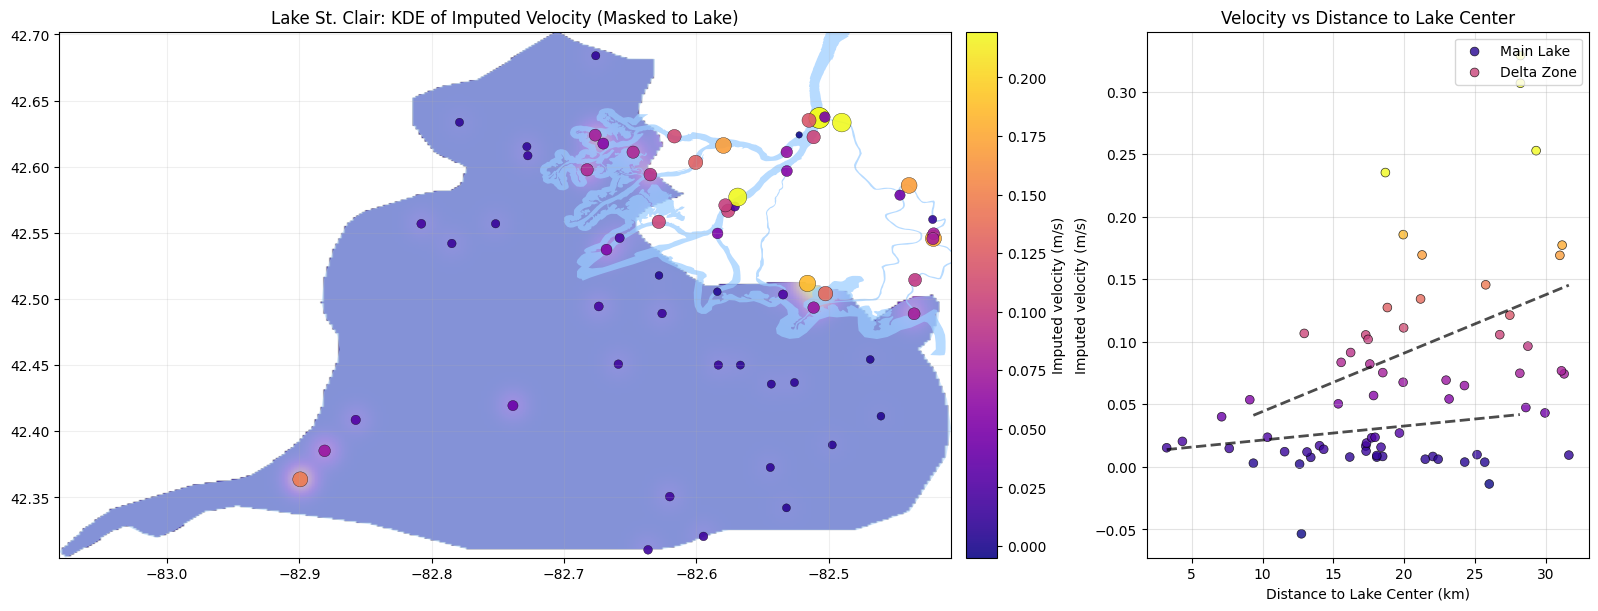

In [2794]:
# KDE velocity surface within Lake St. Clair, with trend vs distance (improved layout)
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Lake polygon (lon/lat for plotting)
lake_stclair = gpd.read_file("../data/maps/lake_stclair/lake_stclair.shp").to_crs(epsg=4326)
lake_union   = lake_stclair.union_all()
lake_boundary = lake_stclair.boundary.union_all()

# Sites and imputed velocities
sites = raw_data.copy()
sites_gdf = gpd.GeoDataFrame(
    sites,
    geometry=gpd.points_from_xy(sites['Longitude'], sites['Latitude']),
    crs='EPSG:4326'
)

is_lsc = sites_gdf['Waterbody'].str.upper().str.contains('LSC')
lsc    = sites_gdf[is_lsc].copy()

# Grid over lake bounds
minx, miny, maxx, maxy = lake_union.bounds
nx, ny = 300, 300
xgrid = np.linspace(minx, maxx, nx)
ygrid = np.linspace(miny, maxy, ny)
xx, yy = np.meshgrid(xgrid, ygrid)

# Mask outside-lake points
grid_points = [Point(xy) for xy in zip(xx.ravel(), yy.ravel())]
mask = np.array([lake_union.contains(p) for p in grid_points]).reshape(xx.shape)

# KDE weighted by imputed velocity (Gaussian kernel)
coords = np.column_stack([lsc.geometry.x.values, lsc.geometry.y.values])
vel    = lsc['Velocity  at bottom (m/sec)_Imputed'].fillna(0).values
bw     = 0.008
bw2    = bw * bw
heat   = np.zeros_like(xx)

for i in range(coords.shape[0]):
    dx = xx - coords[i, 0]
    dy = yy - coords[i, 1]
    w  = np.exp(-(dx*dx + dy*dy) / (2*bw2))
    heat += vel[i] * w

# Apply mask and normalize for color scaling
heat[~mask] = np.nan
norm = Normalize(vmin=np.nanmin(heat), vmax=np.nanmax(heat))

# Distances to center/shore (for trend)
lake_centroid = lake_union.centroid
lsc['dist_shore_deg']  = lsc.geometry.apply(lambda g: g.distance(lake_boundary))
lsc['dist_center_deg'] = lsc.geometry.apply(lambda g: g.distance(lake_centroid))

# Figure
fig, (ax_map, ax_trend) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2.4, 1]}, constrained_layout=True)

# Base map
stclair_river = gpd.read_file("../data/maps/aoc_mi_stclair_2021/AOC_MI_StClair_2021.shp").to_crs(epsg=4326)
lake_stclair.plot(ax=ax_map, color='#b3d8ff', edgecolor='none', alpha=0.6)
stclair_river.plot(ax=ax_map, color='#99ccff', edgecolor='none', alpha=0.7)

# KDE heat
im = ax_map.imshow(heat, origin='lower', extent=[minx, maxx, miny, maxy], cmap='plasma', norm=norm, alpha=0.85)

# Site points colored by velocity
sc = ax_map.scatter(lsc.geometry.x, lsc.geometry.y,
                    c=lsc['Velocity  at bottom (m/sec)_Imputed'],
                    s=lsc['Velocity  at bottom (m/sec)_Imputed'] * 600 + 30,  # Size proportional to velocity
                    cmap='plasma',
                    norm=norm,
                    edgecolors='k',
                    linewidths=0.25,
                    alpha=0.9)

# Colorbar
divider = make_axes_locatable(ax_map)
cax = divider.append_axes("right", size="3.5%", pad=0.15)
cbar = plt.colorbar(sc, cax=cax)
cbar.set_label('Imputed velocity (m/s)')

ax_map.set_title('Lake St. Clair: KDE of Imputed Velocity (Masked to Lake)')
ax_map.set_xlim(minx, maxx)
ax_map.set_ylim(miny, maxy)
ax_map.grid(alpha=0.2)

# Trend subplot: velocity vs distance to lake center (km)
km_factor = 111.0
lsc_main     = lsc[~delta_zone_mask]
lsc_delta = lsc[delta_zone_mask]

for subset in [lsc_main, lsc_delta]:
    center_km = subset['dist_center_deg'] * km_factor
    ax_trend.scatter(center_km, subset['Velocity  at bottom (m/sec)_Imputed'], 
                     c=subset['Velocity  at bottom (m/sec)_Imputed'],
                     s=40,
                     cmap='plasma',
                     label = 'Delta Zone' if subset is lsc_delta else 'Main Lake',
                     norm=norm,
                     edgecolors='k',
                     linewidths=0.5,
                     alpha=0.8)
    z = np.polyfit(center_km, subset['Velocity  at bottom (m/sec)_Imputed'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(center_km.min(), center_km.max(), 100)
    ax_trend.plot(x_trend, p(x_trend), 'k--', linewidth=2, alpha=0.7)

ax_trend.set_xlabel('Distance to Lake Center (km)')
ax_trend.set_ylabel('Imputed velocity (m/s)')
ax_trend.set_title('Velocity vs Distance to Lake Center')
ax_trend.legend(loc='upper right')
ax_trend.grid(alpha=0.35)

plt.show()

### Impute the water velocity data for St. Clair River

To the sites in **St. Clair River**, their Water Velocity data will be imputed using the median water velocity of sites in Detroit River with some random noise added.

Previous imputation for sites in LSC **did not** impute any missing values for sites in **SCR**, it is safe to impute these sites and **merge them back** to the main dataset.

In [2795]:
# Impute water velocities for St. Clair River (SCR) sites
import numpy as np
import geopandas as gpd

# Work on a copy to avoid side-effects
sites = raw_data.copy()
sites_gdf = gpd.GeoDataFrame(
    sites,
    geometry=gpd.points_from_xy(sites['Longitude'], sites['Latitude']),
    crs='EPSG:4326'
 )

# Identify SCR sites by Waterbody label
is_scr = sites_gdf['Waterbody'].str.upper().str.contains('SCR') | \
         sites_gdf['Waterbody'].str.upper().str.contains('ST. CLAIR RIVER')
scr_sites = sites_gdf[is_scr].copy()

# Use Detroit River median velocity as baseline
baseline = float(dr_median_velocity)

# Randomness: small normal noise scaled by baseline
# Keep values positive and within a reasonable band
noise = rng.normal(loc=0.0, scale=0.5 * baseline, size=len(scr_sites))
scale = rng.uniform(0.5, 1.5, size=len(scr_sites))  # scaling factor
scr_velocity = np.clip(scale * baseline + noise, 0.01, None)

# Initialize Velocity_Imputed
sites['Velocity_Imputed'] = sites["Velocity  at bottom (m/sec)_Imputed"].copy()

# Assign imputed velocities to SCR indices
sites.loc[scr_sites.index, 'Velocity_Imputed'] = scr_velocity

# Persist back to raw_data used downstream
raw_data['Velocity  at bottom (m/sec)_Imputed'] = sites['Velocity_Imputed']

# Print summary of SCR imputation
print("St. Clair River (SCR) imputation summary:")
print(f"  SCR sites identified: {is_scr.sum()} of {len(sites)} total")
print(f"  DR median velocity baseline: {baseline:.3f} m/s")
print(f"  Imputed velocity range: {scr_velocity.min():.3f} to {scr_velocity.max():.3f} m/s")
print(f"  SCR median velocity: {np.median(scr_velocity):.3f} m/s")
print(f"  Ratio to DR median: {np.median(scr_velocity)/baseline:.1f}x")

St. Clair River (SCR) imputation summary:
  SCR sites identified: 20 of 104 total
  DR median velocity baseline: 0.188 m/s
  Imputed velocity range: 0.085 to 0.306 m/s
  SCR median velocity: 0.176 m/s
  Ratio to DR median: 0.9x


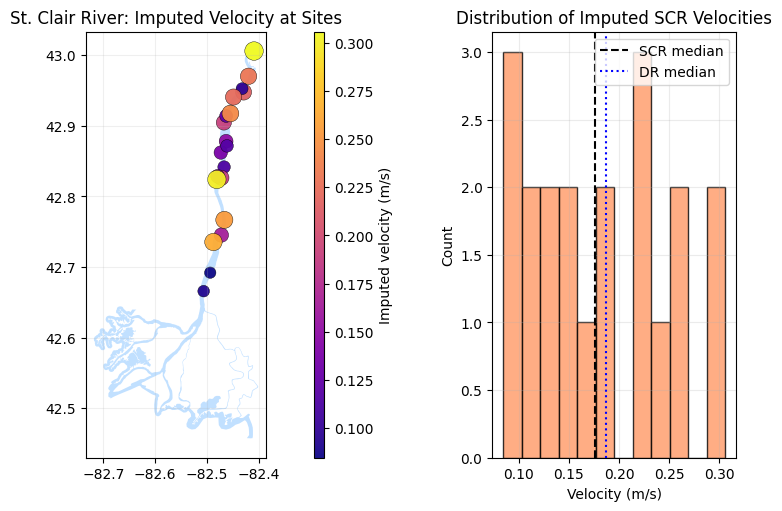

In [2796]:
# Visualize imputed velocities for St. Clair River (SCR)
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Reconstruct GeoDataFrame and SCR subset
sites = raw_data.copy()
sites_gdf = gpd.GeoDataFrame(
    sites,
    geometry=gpd.points_from_xy(sites['Longitude'], sites['Latitude']),
    crs='EPSG:4326'
)

is_scr = sites_gdf['Waterbody'].str.upper().str.contains('SCR') | \
         sites_gdf['Waterbody'].str.upper().str.contains('ST. CLAIR RIVER')
scr = sites_gdf[is_scr].copy()

# Load St. Clair River geometry for context
stclair_river = gpd.read_file("../data/maps/aoc_mi_stclair_2021/AOC_MI_StClair_2021.shp").to_crs(epsg=4326)

fig, (ax_map, ax_hist) = plt.subplots(1, 2, figsize=(8, 5), gridspec_kw={'width_ratios': [2, 1]}, constrained_layout=True)

# Map: SCR sites colored by imputed velocity
stclair_river.plot(ax=ax_map, color='#99ccff', edgecolor='none', alpha=0.6)
sc = ax_map.scatter(scr.geometry.x, scr.geometry.y,
                    c=scr['Velocity  at bottom (m/sec)_Imputed'],
                    s=scr['Velocity  at bottom (m/sec)_Imputed'] * 500 + 25,
                    cmap='plasma',
                    edgecolors='k',
                    linewidths=0.3,
                    alpha=0.95)
ax_map.set_title('St. Clair River: Imputed Velocity at Sites')
ax_map.grid(alpha=0.2)

# Colorbar
divider = make_axes_locatable(ax_map)
cax = divider.append_axes("right", size="4%", pad=0.15)
plt.colorbar(sc, cax=cax, label='Imputed velocity (m/s)')

# Histogram: distribution of imputed velocities
vals = scr['Velocity  at bottom (m/sec)_Imputed'].dropna().values
ax_hist.hist(vals, bins=12, color='#ff9966', alpha=0.8, edgecolor='k')
ax_hist.axvline(np.median(vals), color='k', linestyle='--', linewidth=1.5, label='SCR median')
ax_hist.axvline(dr_median_velocity, color='blue', linestyle=':', linewidth=1.5, label='DR median')
ax_hist.set_title('Distribution of Imputed SCR Velocities')
ax_hist.set_xlabel('Velocity (m/s)')
ax_hist.set_ylabel('Count')
ax_hist.legend()
ax_hist.grid(alpha=0.25)

plt.show()


In [2797]:
# a function to plot the spatial distribution and comparative barplot of the references
import seaborn as sns
from scipy.stats import f_oneway
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# define a function to read the shp files and quickly plot the lake and river maps
def plot_rivers_lakes(ax = None, annotating = False):
    """Plot the Detroit River with adjacent lakes."""
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure
        
    # read the two shape files of the lakes
    lake_stclair = gpd.read_file("../data/maps/lake_stclair/lake_stclair.shp")
    lake_erie = gpd.read_file("../data/maps/lake_erie/lake_erie.shp")
    detroit_river = gpd.read_file("../data/maps/detroit_river_aoc_shapefile/AOC_MI_Detroit_2021.shp")
    stclair_river = gpd.read_file("../data/maps/aoc_mi_stclair_2021/AOC_MI_StClair_2021.shp")
    lake_huron = gpd.read_file("../data/maps/lake_huron/lake_huron.shp")
    
    # plot the Detroit River and the lakes
    lake_stclair.plot(ax=ax, color='lightblue', edgecolor='none', alpha=0.5)
    lake_erie.plot(ax=ax, color='lightblue', edgecolor='none', alpha=0.5)
    lake_huron.plot(ax=ax, color='lightblue', edgecolor='none', alpha=0.5)
    detroit_river.plot(ax=ax, color='lightblue', edgecolor='none')
    stclair_river.plot(ax=ax, color='lightblue', edgecolor='none')
    ax.set_title("The Huron-Erie Corridor")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_ylim(42, 43.1)  # Set y-limits to focus on North America
    ax.set_xlim(-83.3, -82.3)  # Set x-limits to focus on North America
    if annotating:
        ax.text(-83.0, 42.2, 'Detroit River', fontsize=8, color = 'gray', style='italic') 
        ax.text(-82.85, 42.9, 'St. Clair River', fontsize=8, color = 'gray', style='italic')
        ax.text(-82.55, 42.05, 'Lake Erie', fontsize=8, color = 'gray', style='italic')
        ax.text(-83.0, 42.5, 'Lake St. Clair', fontsize=8, color = 'gray', style='italic')
        ax.text(-82.6, 43.05, 'Lake Huron', fontsize=8, color = 'gray', style='italic')
    return fig, ax

def plot_feature_analysis(df, feature_name, lat_col='Latitude', lon_col='Longitude', waterbody_col='Waterbody'):
    """
    Plot a specific habitat feature's spatial distribution and statistical analysis.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the data
    feature_name : str
        Name of the feature column to analyze
    lat_col : str
        Name of the latitude column (default: 'Latitude')
    lon_col : str
        Name of the longitude column (default: 'Longitude')
    waterbody_col : str
        Name of the waterbody column (default: 'Waterbody')
    """
    
    # Create a figure with three subplots: left for map, right side split into two
    fig = plt.figure(figsize=(10, 6), dpi=300)

    # Create subplot layout: left panel takes 1/2 width, right panel split into 2 rows
    ax1 = plt.subplot2grid((2, 2), (0, 0), rowspan=2)  # Map spans full left side (1/2 width)
    ax2 = plt.subplot2grid((2, 2), (0, 1))  # Upper right: ridge plot comparison
    ax3 = plt.subplot2grid((2, 2), (1, 1))  # Lower right: ANOVA test results

    # Left panel: Spatial distribution map
    plot_rivers_lakes(ax=ax1, annotating=True)
    # Normalize the feature values to create relative sizes
    feature_values = df[feature_name]
    normalized_sizes = ((feature_values - feature_values.min()) / 
                       (feature_values.max() - feature_values.min()) * 100 + 5)
    
    sc = ax1.scatter(df[lon_col], df[lat_col], c=df[feature_name], 
                     s=normalized_sizes, cmap='viridis', alpha=0.7)
    ax1.set_title(f"Spatial Distribution of {feature_name}", fontsize=14, fontweight='bold')
    ax1.grid(linestyle='--', alpha=0.5)

    # Add colorbar for the scatter plot
    cbar = plt.colorbar(sc, ax=ax1, shrink=0.8)
    cbar.set_label(feature_name, fontsize=12)

    # Upper right: Ridge plot-style comparison across waterbodies
    waterbodies = df[waterbody_col].unique()

    # Create blue gradient colors
    n_bodies = len(waterbodies)
    colors = plt.cm.Blues(np.linspace(0.3, 0.9, n_bodies))

    # Set up the ridge plot parameters
    ridge_height = 0.8  # Height of each ridge
    ridge_spacing = 1.0  # Vertical spacing between ridges
    baseline_offset = 0.1  # Small offset from baseline

    # Clear the axis and set up for ridge plot
    ax2.clear()

    # Create ridge plot with proper stacking
    for i, wb in enumerate(waterbodies):
        data_wb = df[df[waterbody_col] == wb][feature_name].dropna()
        if len(data_wb) > 1:
            # Create smooth density curve using Gaussian KDE
            kde = gaussian_kde(data_wb)
            
            # Create x values for smooth curve
            x_min, x_max = data_wb.min(), data_wb.max()
            x_range = x_max - x_min
            x_smooth = np.linspace(x_min - 0.1*x_range, x_max + 0.1*x_range, 200)
            
            # Calculate density values
            density = kde(x_smooth)
            
            # Normalize density to ridge height
            normalized_density = (density / density.max()) * ridge_height
            
            # Calculate y position for this ridge (bottom to top)
            y_baseline = i * ridge_spacing
            y_values = y_baseline + normalized_density + baseline_offset
            
            # Create the filled area
            ax2.fill_between(x_smooth, y_baseline + baseline_offset, y_values, 
                            color=colors[i], alpha=0.8, edgecolor='white', linewidth=0.5)
            
            # Add a subtle baseline for each ridge
            ax2.axhline(y=y_baseline + baseline_offset, color='lightgray', 
                       linestyle='-', linewidth=0.5, alpha=0.7)

    # Set up the y-axis
    ax2.set_ylim(-0.2, len(waterbodies) * ridge_spacing + 0.5)
    ax2.set_yticks([i * ridge_spacing + baseline_offset + ridge_height/2 for i in range(len(waterbodies))])
    ax2.set_yticklabels(waterbodies, fontsize=11)

    # Style the plot
    ax2.set_title(f"Overlapping densities ('ridge plot')", fontsize=10, fontweight='bold')
    ax2.set_xlabel(feature_name, fontsize=11)
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    # Lower right: ANOVA test results with bar plot
    waterbody_groups = [df[df[waterbody_col] == wb][feature_name].dropna() 
                       for wb in waterbodies]
    f_stat, p_value = f_oneway(*waterbody_groups)

    # Calculate means and standard errors
    means = [group.mean() for group in waterbody_groups]
    std_errors = [group.std() / np.sqrt(len(group)) for group in waterbody_groups]

    # Create bar plot with error bars using the same blue gradient
    bars = ax3.bar(waterbodies, means, yerr=std_errors, 
                   alpha=0.8, color=colors, capsize=5, 
                   error_kw={'linewidth': 2, 'markeredgewidth': 2})

    # Add value labels on bars
    for i, (bar, mean) in enumerate(zip(bars, means)):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + std_errors[i] + height*0.02,
                 f'{mean:.2f}', ha='center', va='bottom', fontweight='bold')

    ax3.set_title(f"ANOVA Test: Mean {feature_name} by Waterbody\nF={f_stat:.3f}, p={p_value:.4f}", 
                  fontsize=10, fontweight='bold')
    ax3.set_ylabel(f"Mean {feature_name} ± SE", fontsize=11)
    ax3.set_xlabel("Waterbody", fontsize=11)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.spines['left'].set_visible(False)

    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.4)

    plt.show()
    
    return fig, f_stat, p_value

/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/var/folders/s5/r1s56_ps46lbbv1370hjn_vr0000gn/T/ipykernel_14445/750963277.py:74: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(velocity_groups, labels=group_labels, patch_artist=True)
/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


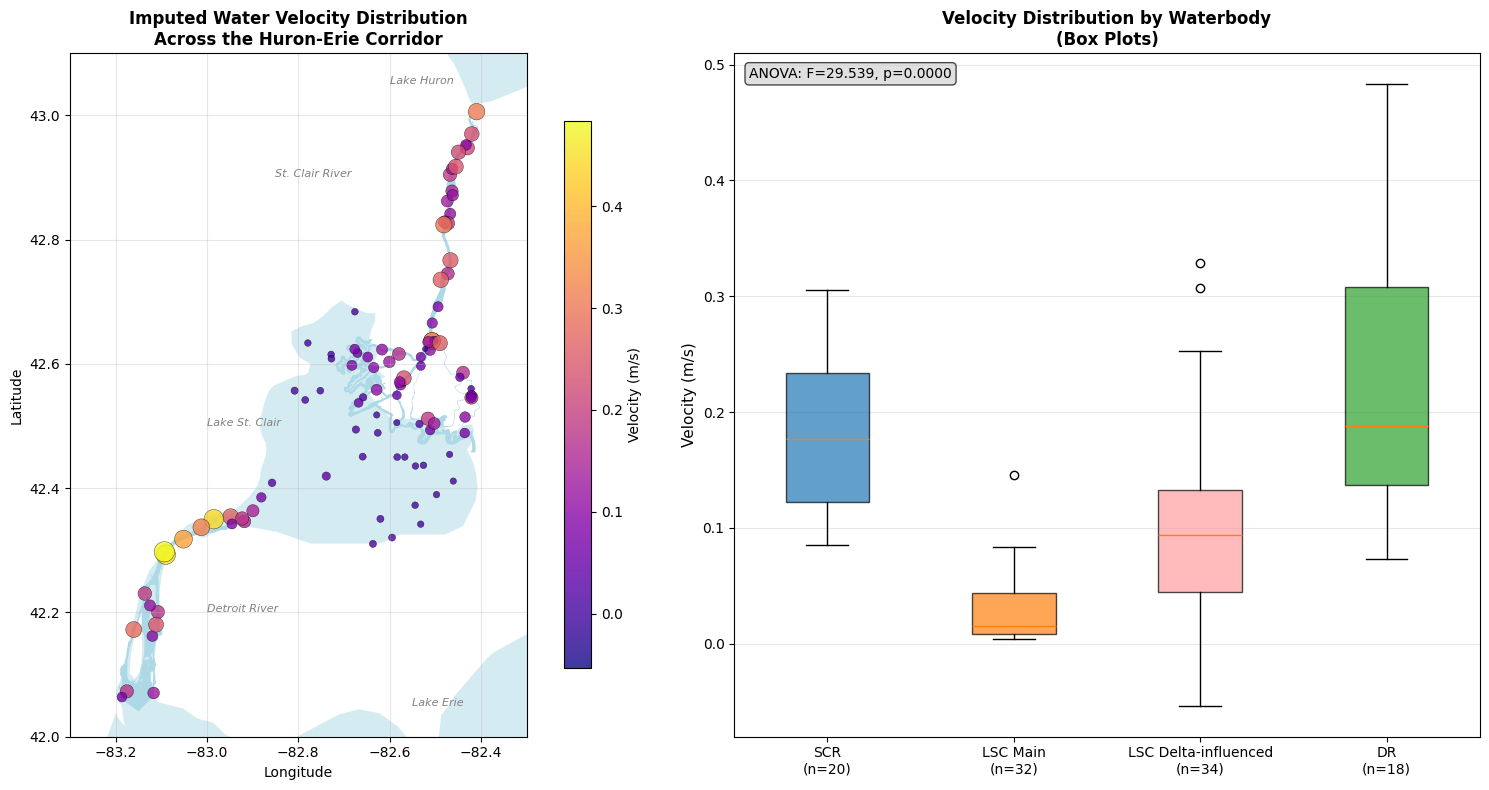


VELOCITY SUMMARY BY WATERBODY (WITH LSC SEPARATION)
Group           Count    Mean     Std      Min      Max     
--------------------------------------------------------------------------------
SCR             20       0.182    0.070    0.085    0.306   
LSC Main        32       0.029    0.033    0.004    0.146   
LSC Delta-influenced 34       0.101    0.088    -0.054   0.329   
DR              18       0.235    0.129    0.073    0.483   

ANOVA: F = 29.539, p = 0.0000 (significant)


In [2798]:
# visualize the all imputed velocity data across the SCDRS
import numpy as np
import seaborn as sns
from scipy.stats import f_oneway

# Visualize the whole imputed velocity data across the entire water area
import matplotlib.pyplot as plt

# Create comprehensive visualization of imputed velocity data
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Prepare velocity data for all sites
all_sites = raw_data.copy()
velocity_col = 'Velocity  at bottom (m/sec)_Imputed'

# 1. Left: Spatial distribution map with velocity
ax1 = axes[0]
plot_rivers_lakes(ax=ax1, annotating=True)

# Plot all sites colored by imputed velocity
sc = ax1.scatter(all_sites['Longitude'], all_sites['Latitude'], 
                c=all_sites[velocity_col], 
                s=all_sites[velocity_col] * 400 + 20,  # Size proportional to velocity
                cmap='plasma', 
                alpha=0.8, 
                edgecolors='black', 
                linewidths=0.3)

ax1.set_title('Imputed Water Velocity Distribution\nAcross the Huron-Erie Corridor', 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add colorbar
cbar1 = plt.colorbar(sc, ax=ax1, shrink=0.8)
cbar1.set_label('Velocity (m/s)', fontsize=10)

# 2. Right: Box plots by waterbody with LSC separation
ax2 = axes[1]

# Separate LSC sites into main lake and delta zone
lsc_sites = all_sites[all_sites['Waterbody'] == 'LSC']
lsc_main = lsc_sites[~delta_zone_mask]  # Main lake sites
lsc_delta = lsc_sites[delta_zone_mask]  # Delta zone sites

# Create data groups for box plots
velocity_groups = []
group_labels = []

# SCR
scr_data = all_sites[all_sites['Waterbody'] == 'SCR'][velocity_col].dropna()
if len(scr_data) > 0:
    velocity_groups.append(scr_data)
    group_labels.append(f'SCR\n(n={len(scr_data)})')

# LSC Main Lake
lsc_main_data = lsc_main[velocity_col].dropna()
if len(lsc_main_data) > 0:
    velocity_groups.append(lsc_main_data)
    group_labels.append(f'LSC Main\n(n={len(lsc_main_data)})')

# LSC Delta Zone
lsc_delta_data = lsc_delta[velocity_col].dropna()
if len(lsc_delta_data) > 0:
    velocity_groups.append(lsc_delta_data)
    group_labels.append(f'LSC Delta-influenced\n(n={len(lsc_delta_data)})')

# DR
dr_data = all_sites[all_sites['Waterbody'] == 'DR'][velocity_col].dropna()
if len(dr_data) > 0:
    velocity_groups.append(dr_data)
    group_labels.append(f'DR\n(n={len(dr_data)})')

# Create box plots
bp = ax2.boxplot(velocity_groups, labels=group_labels, patch_artist=True)

# Color the box plots
colors = ['#1f77b4', '#ff7f0e', '#ff9f9f', '#2ca02c']  # Different colors for each group
for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_ylabel('Velocity (m/s)', fontsize=11)
ax2.set_title('Velocity Distribution by Waterbody\n(Box Plots)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add statistical annotations if needed
# Perform ANOVA across groups
if len(velocity_groups) > 1:
    f_stat, p_value = f_oneway(*velocity_groups)
    ax2.text(0.02, 0.98, f'ANOVA: F={f_stat:.3f}, p={p_value:.4f}', 
             transform=ax2.transAxes, fontsize=10, 
             verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 80)
print("VELOCITY SUMMARY BY WATERBODY (WITH LSC SEPARATION)")
print("=" * 80)
print(f"{'Group':<15} {'Count':<8} {'Mean':<8} {'Std':<8} {'Min':<8} {'Max':<8}")
print("-" * 80)

for i, (group_data, label) in enumerate(zip(velocity_groups, group_labels)):
    group_name = label.split('\n')[0]
    print(f"{group_name:<15} {len(group_data):<8} {group_data.mean():<8.3f} {group_data.std():<8.3f} "
          f"{group_data.min():<8.3f} {group_data.max():<8.3f}")

if len(velocity_groups) > 1:
    print(f"\nANOVA: F = {f_stat:.3f}, p = {p_value:.4f} ({'significant' if p_value < 0.05 else 'not significant'})")
print("=" * 80)


Adds the imputed water velocity to the dataframe as a new column named `Velocity  at bottom (m/sec)_Imputed`.

It's alread in the `raw_data` dataframe.

In [2799]:
# add the complete imputed data to the data
data[("environmental", "raw", "Velocity at bottom (m/sec)_Imputed")] = raw_data["Velocity  at bottom (m/sec)_Imputed"].copy()
print("Imputed velocity data added to the dataset under ('environmental', 'raw', 'Velocity at bottom (m/sec)_Imputed')")
print(f"First 5 entries:\n{data[('environmental', 'raw', 'Velocity at bottom (m/sec)_Imputed')].head()}")

Imputed velocity data added to the dataset under ('environmental', 'raw', 'Velocity at bottom (m/sec)_Imputed')
First 5 entries:
StationID
A10    0.190172
A23    0.105506
A27    0.009388
A28    0.177290
A29    0.096495
Name: (environmental, raw, Velocity at bottom (m/sec)_Imputed), dtype: float64


## Select reference sites

With the end of 02_Contamination_Assessment notebook, every site has a contaminatoin score that can be used to rank their pollution compareably. Read the data and select the top $p$ **least-pollutant sites** as prinstine sites for studying 'environmental-taxa' equation is feasible.

Subjectively choose the first $p$ percent sites as reference sites.

In [2800]:
# set p percentage of sites to select as reference
p = 52

In [2801]:
# choose p% lowest scores sites as reference sites
pollution_scores = raw_data['SumRel']
n_reference_sites = int(len(pollution_scores) * p / 100)
reference_sites = pollution_scores.nsmallest(n_reference_sites)
raw_reference_data = raw_data.loc[reference_sites.index]
reference_data = data.loc[reference_sites.index]

print(f"Selected {n_reference_sites} reference sites ({p}% of {len(raw_data)} total sites)")
print(f"Pollution scores range: {reference_sites.min():.3f} to {reference_sites.max():.3f}")
print(f"Reference sites: {list(reference_sites.index)}")

Selected 54 reference sites (52% of 104 total sites)
Pollution scores range: -4.401 to -0.243
Reference sites: ['S96', 'S93', 'A66', 'DCC2', 'S70', 'S54', 'S72', 'S74', 'GL1', 'S51', 'S65', 'S53', 'S56', 'S60', 'S102', 'S41', 'S69', 'S68', 'S28', 'S63', 'S20', 'S67', 'A5', 'S1', 'S50', 'S8', 'S37', 'S28(5)', 'S39', 'S62', 'S21(5)', 'A6', 'S17', 'S44', 'A53', 'S49', 'S81', 'A28', 'DCE3', 'S82', 'S38', 'UCE1', 'S47', 'S18', 'S43', 'S87', 'S45', 'S9', 'S25', 'S84', 'S79', 'S94', 'S55', 'S83']


Before finally decide a good $p$ value, we can first visualize the pollution step plot to choose an as higher $p$ as possible to have more reference sites.

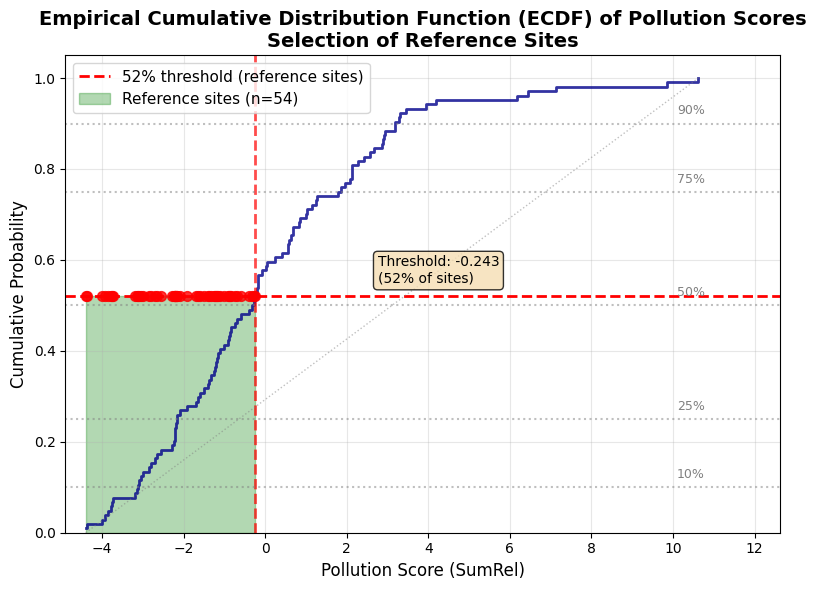

Pollution Score Distribution Summary:
Total sites: 104
Score range: -4.401 to 10.622
Reference sites threshold: -0.243
Reference sites scores range: -4.401 to -0.243

Percentiles:
  10th percentile: -3.116
  25th percentile: -2.164
  50th percentile: -0.310
  75th percentile: 1.805
  90th percentile: 3.190
  95th percentile: 4.156


In [2802]:
# create step plot to visualize the empirical cumulative density function of pollution scores
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Sort pollution scores for CDF
sorted_scores = raw_data['SumRel'].sort_values()

# Create empirical CDF
n_sites = len(sorted_scores)
cumulative_prob = np.arange(1, n_sites + 1) / n_sites

# Plot the ECDF as a step plot
plt.step(sorted_scores, cumulative_prob, where='post', linewidth=2, color='darkblue', alpha=0.8)

# Add reference sites threshold line
reference_threshold = reference_sites.max()
reference_percentile = p / 100

plt.axhline(y=reference_percentile, color='red', linestyle='--', linewidth=2, 
           label=f'{p}% threshold (reference sites)')
plt.axvline(x=reference_threshold, color='red', linestyle='--', linewidth=2, alpha=0.7)

# Highlight reference sites region
plt.fill_between(sorted_scores[sorted_scores <= reference_threshold], 
                 0, reference_percentile, alpha=0.3, color='green', 
                 label=f'Reference sites (n={n_reference_sites})')

# Add markers for selected reference sites
plt.scatter(reference_sites, [p/100] * len(reference_sites), 
           color='red', s=50, zorder=5, alpha=0.8)

# Add a diagonal line of y=x for reference
plt.plot([sorted_scores.min(), sorted_scores.max()], 
         [0, 1], color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Styling
plt.xlabel('Pollution Score (SumRel)', fontsize=12)
plt.ylabel('Cumulative Probability', fontsize=12)
plt.title('Empirical Cumulative Distribution Function (ECDF) of Pollution Scores\nSelection of Reference Sites', 
         fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Add text annotations
plt.text(reference_threshold + 3, reference_percentile + 0.03, 
         f'Threshold: {reference_threshold:.3f}\n({p}% of sites)', 
         fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Add percentile markers on y-axis
percentiles = [10, 25, 50, 75, 90]
for pct in percentiles:
    score_at_pct = np.percentile(sorted_scores, pct)
    plt.axhline(y=pct/100, color='gray', linestyle=':', alpha=0.5)
    plt.text(sorted_scores.max() * 0.95, pct/100 + 0.02, f'{pct}%', 
             fontsize=9, color='gray')

plt.ylim(0, 1.05)
plt.xlim(sorted_scores.min() - 0.5, sorted_scores.max() + 2)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Pollution Score Distribution Summary:")
print(f"Total sites: {n_sites}")
print(f"Score range: {sorted_scores.min():.3f} to {sorted_scores.max():.3f}")
print(f"Reference sites threshold: {reference_threshold:.3f}")
print(f"Reference sites scores range: {reference_sites.min():.3f} to {reference_sites.max():.3f}")
print(f"\nPercentiles:")
for pct in [10, 25, 50, 75, 90, 95]:
    score = np.percentile(sorted_scores, pct)
    print(f"  {pct}th percentile: {score:.3f}")

In [2803]:
# choose the test sites as the complement of reference sites (highest pollution scores)
test_pollution_scores = raw_data['SumRel'].drop(reference_sites.index)
n_deg = 20
deg_sites_index = test_pollution_scores.nlargest(n_deg).index
raw_deg_data = raw_data.loc[deg_sites_index]
deg_data = data.loc[deg_sites_index]

print(f"Selected {len(deg_sites_index)} test sites (remaining {100-n_deg}% of {len(raw_data)} total sites)")
print(f"Test sites pollution scores range: {raw_deg_data['SumRel'].min():.3f} to {raw_deg_data['SumRel'].max():.3f}")
print(f"Test sites: {list(deg_sites_index)}")

Selected 20 test sites (remaining 80% of 104 total sites)
Test sites pollution scores range: 2.279 to 10.622
Test sites: ['S85', 'S3', 'S10', 'S4', 'S12', 'S5', 'S21', 'UJC1', 'S36', 'S100', 'S89', 'S98', 'S15', 'DJC2', 'S13', 'S78', 'DBC2', 'MCE2', 'S57', 'S48']


In [2804]:
# select the test sites between reference and deg sites
intermediate_pollution_scores = test_pollution_scores.drop(deg_sites_index)
intermediate_sites_index = intermediate_pollution_scores.index
raw_intermediate_data = raw_data.loc[intermediate_sites_index]
intermediate_data = data.loc[intermediate_sites_index]

print(f"Selected {len(intermediate_sites_index)} intermediate test sites (between reference and DEG sites)")
print(f"Intermediate test sites pollution scores range: {raw_intermediate_data['SumRel'].min():.3f} to {raw_intermediate_data['SumRel'].max():.3f}")
print(f"Intermediate test sites: {list(intermediate_sites_index)}")

Selected 30 intermediate test sites (between reference and DEG sites)
Intermediate test sites pollution scores range: -0.210 to 2.137
Intermediate test sites: ['A10', 'A23', 'A27', 'A29', 'A58', 'S101', 'S11', 'S14', 'S16', 'S19', 'S22', 'S23', 'S24', 'S27', 'S27(5)', 'S40', 'S42', 'S46', 'S52', 'S58', 'S61', 'S64', 'S66', 'S80', 'S90', 'S95', 'S97', 'S99', 'UBC1', 'UCC1']


Visualize where the $p\%$ sites are and levels of their raw chemical concentrations.

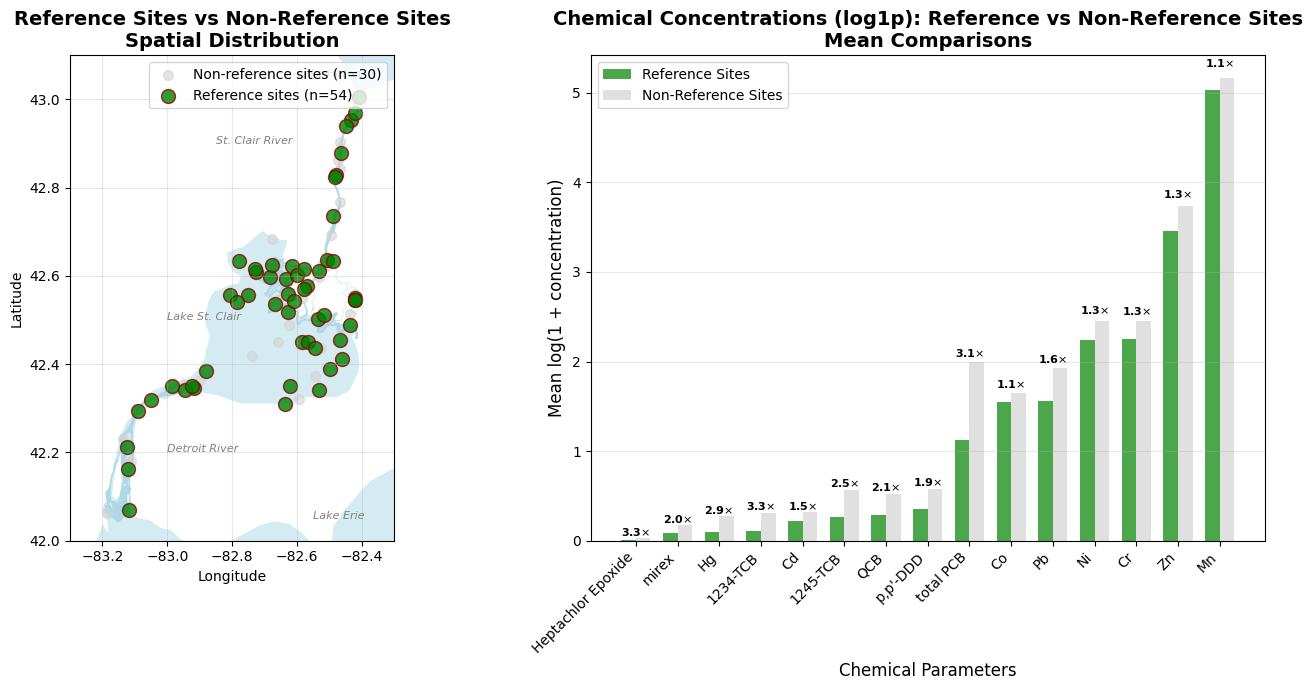


Reference Sites Summary:
Number of sites: 54
Pollution score range: -4.401 to -0.243
Waterbodies represented: {'LSC': 37, 'DR': 9, 'SCR': 8}

Non-Reference Sites Summary:
Number of sites: 30
Pollution score range: -0.210 to 2.137


In [2805]:
# Create a comprehensive comparison plot of reference vs non-reference sites
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Left panel: Spatial distribution showing reference vs non-reference sites
plot_rivers_lakes(ax=ax1, annotating=True)

# Identify non-reference sites
non_reference_sites = raw_data.loc[~raw_data.index.isin(reference_sites.index)]

# Plot non-reference sites in gray
ax1.scatter(raw_intermediate_data['Longitude'], raw_intermediate_data['Latitude'], 
           c='lightgray', s=50, alpha=0.6, label=f'Non-reference sites (n={len(raw_intermediate_data)})')

# Plot reference sites in green
ax1.scatter(raw_reference_data['Longitude'], raw_reference_data['Latitude'], 
           c='green', s=100, alpha=0.8, edgecolors='darkred', linewidths=1,
           label=f'Reference sites (n={n_reference_sites})')

ax1.set_title('Reference Sites vs Non-Reference Sites\nSpatial Distribution', 
             fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
# Right panel: Chemical comparison between reference and non-reference sites
# Select key chemical columns (excluding biological and coordinate data)
chemical_cols = ['Heptachlor Epoxide', "p,p'-DDD", 'QCB', '1234-TCB', 'Cd', 'Co', 'Cr', 'mirex', 'total PCB', 
                'Hg', 'Mn', 'Ni', 'Pb', 'Zn', '1245-TCB']

# Apply log(1 + x) transformation to concentrations before computing means
ref_log1p = np.log1p(raw_reference_data[chemical_cols])
non_ref_log1p = np.log1p(raw_intermediate_data[chemical_cols])

# Calculate means for reference sites and sort by absolute values (ascending)
ref_means_for_sorting = ref_log1p.mean()
chemical_cols = ref_means_for_sorting.abs().sort_values().index.tolist()

# Calculate means for both groups in log1p scale
ref_means = ref_log1p[chemical_cols].mean()
non_ref_means = non_ref_log1p[chemical_cols].mean()

# Create comparison DataFrame in log1p scale
comparison_data = pd.DataFrame({
    'Reference Sites (log1p)': ref_means,
    'Non-Reference Sites (log1p)': non_ref_means
})

# Create bar plot
x_pos = np.arange(len(chemical_cols))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, comparison_data['Reference Sites (log1p)'], 
               width, label='Reference Sites', color='green', alpha=0.7)
bars2 = ax2.bar(x_pos + width/2, comparison_data['Non-Reference Sites (log1p)'], 
               width, label='Non-Reference Sites', color='lightgray', alpha=0.7)

# Customize the plot
ax2.set_xlabel('Chemical Parameters', fontsize=12)
ax2.set_ylabel('Mean log(1 + concentration)', fontsize=12)
ax2.set_title('Chemical Concentrations (log1p): Reference vs Non-Reference Sites\nMean Comparisons', 
             fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(chemical_cols, rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars for key differences (in log1p scale)
for i, (ref_val, non_ref_val) in enumerate(zip(comparison_data['Reference Sites (log1p)'], 
                                              comparison_data['Non-Reference Sites (log1p)'])):
    # Compare on original scale via ratio for interpretability
    ref_orig = np.expm1(ref_val)
    non_ref_orig = np.expm1(non_ref_val)
    ratio = non_ref_orig / ref_orig if ref_orig != 0 else float('inf')
    if ratio > 1 or ratio < 0.5:  # Show label if difference is substantial
        ax2.text(i, max(ref_val, non_ref_val) * 1.02, f'{ratio:.1f}$\\times$', 
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics in both original and log1p scales
print(f"\nReference Sites Summary:")
print(f"Number of sites: {len(raw_reference_data)}")
print(f"Pollution score range: {raw_reference_data['SumRel'].min():.3f} to {raw_reference_data['SumRel'].max():.3f}")
print(f"Waterbodies represented: {raw_reference_data['Waterbody'].value_counts().to_dict()}")

print(f"\nNon-Reference Sites Summary:")
print(f"Number of sites: {len(raw_intermediate_data)}")
print(f"Pollution score range: {raw_intermediate_data['SumRel'].min():.3f} to {raw_intermediate_data['SumRel'].max():.3f}")

Plot the spatial distribution of degraded sites versus non-reference sites.

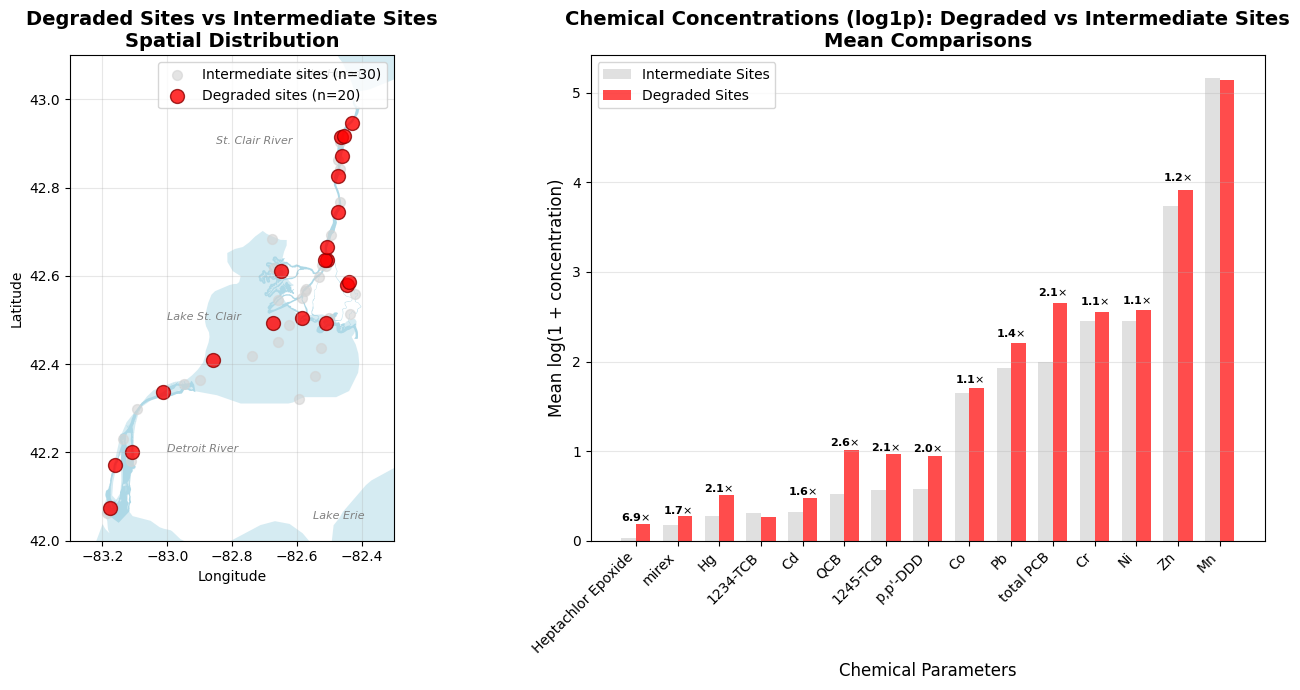


Intermediate Sites Summary:
Number of sites: 30
Pollution score range: -0.210 to 2.137
Waterbodies represented: {'LSC': 20, 'SCR': 5, 'DR': 5}

Degraded Sites Summary:
Number of sites: 20
Pollution score range: 2.279 to 10.622
Waterbodies represented: {'LSC': 9, 'SCR': 7, 'DR': 4}


In [2806]:
# Create a comprehensive comparison plot of degraded vs reference sites
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Left panel: Spatial distribution showing degraded vs reference sites
plot_rivers_lakes(ax=ax1, annotating=True)

# Plot intermediate sites in lightgray first (background)
ax1.scatter(raw_intermediate_data['Longitude'], raw_intermediate_data['Latitude'], 
           c='lightgray', s=50, alpha=0.6, label=f'Intermediate sites (n={len(raw_intermediate_data)})')

# Plot degraded sites in red (foreground)
ax1.scatter(raw_deg_data['Longitude'], raw_deg_data['Latitude'], 
           c='red', s=100, alpha=0.8, edgecolors='darkred', linewidths=1,
           label=f'Degraded sites (n={len(raw_deg_data)})')

ax1.set_title('Degraded Sites vs Intermediate Sites\nSpatial Distribution', 
             fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right panel: Chemical comparison between degraded and reference sites
# Select key chemical columns (excluding biological and coordinate data)
chemical_cols = ['Heptachlor Epoxide', "p,p'-DDD", 'QCB', '1234-TCB', 'Cd', 'Co', 'Cr', 'mirex', 'total PCB', 
                'Hg', 'Mn', 'Ni', 'Pb', 'Zn', '1245-TCB']

# Apply log(1 + x) transformation to concentrations before computing means
inter_log1p = np.log1p(raw_intermediate_data[chemical_cols])
deg_log1p = np.log1p(raw_deg_data[chemical_cols])

# Calculate means for reference sites and sort by absolute values (ascending)
inter_means_for_sorting = inter_log1p.mean()
chemical_cols = inter_means_for_sorting.abs().sort_values().index.tolist()

# Calculate means for both groups in log1p scale
inter_means = inter_log1p[chemical_cols].mean()
deg_means = deg_log1p[chemical_cols].mean()

# Create comparison DataFrame in log1p scale
comparison_data = pd.DataFrame({
    'Intermediate Sites (log1p)': inter_means,
    'Degraded Sites (log1p)': deg_means
})

# Create bar plot
x_pos = np.arange(len(chemical_cols))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, comparison_data['Intermediate Sites (log1p)'], 
               width, label='Intermediate Sites', color='lightgray', alpha=0.7)
bars2 = ax2.bar(x_pos + width/2, comparison_data['Degraded Sites (log1p)'], 
               width, label='Degraded Sites', color='red', alpha=0.7)

# Customize the plot
ax2.set_xlabel('Chemical Parameters', fontsize=12)
ax2.set_ylabel('Mean log(1 + concentration)', fontsize=12)
ax2.set_title('Chemical Concentrations (log1p): Degraded vs Intermediate Sites\nMean Comparisons', 
             fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(chemical_cols, rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars for key differences (in log1p scale)
for i, (inter_val, deg_val) in enumerate(zip(comparison_data['Intermediate Sites (log1p)'], 
                                          comparison_data['Degraded Sites (log1p)'])):
    # Compare on original scale via ratio for interpretability
    inter_orig = np.expm1(inter_val)
    deg_orig = np.expm1(deg_val)
    ratio = deg_orig / inter_orig if inter_orig != 0 else float('inf')
    if ratio > 1 or ratio < 0.5:  # Show label if difference is substantial
        ax2.text(i, max(inter_val, deg_val) * 1.02, f'{ratio:.1f}$\\times$', 
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics in both original and log1p scales
print(f"\nIntermediate Sites Summary:")
print(f"Number of sites: {len(raw_intermediate_data)}")
print(f"Pollution score range: {raw_intermediate_data['SumRel'].min():.3f} to {raw_intermediate_data['SumRel'].max():.3f}")
print(f"Waterbodies represented: {raw_intermediate_data['Waterbody'].value_counts().to_dict()}")

print(f"\nDegraded Sites Summary:")
print(f"Number of sites: {len(raw_deg_data)}")
print(f"Pollution score range: {raw_deg_data['SumRel'].min():.3f} to {raw_deg_data['SumRel'].max():.3f}")
print(f"Waterbodies represented: {raw_deg_data['Waterbody'].value_counts().to_dict()}")


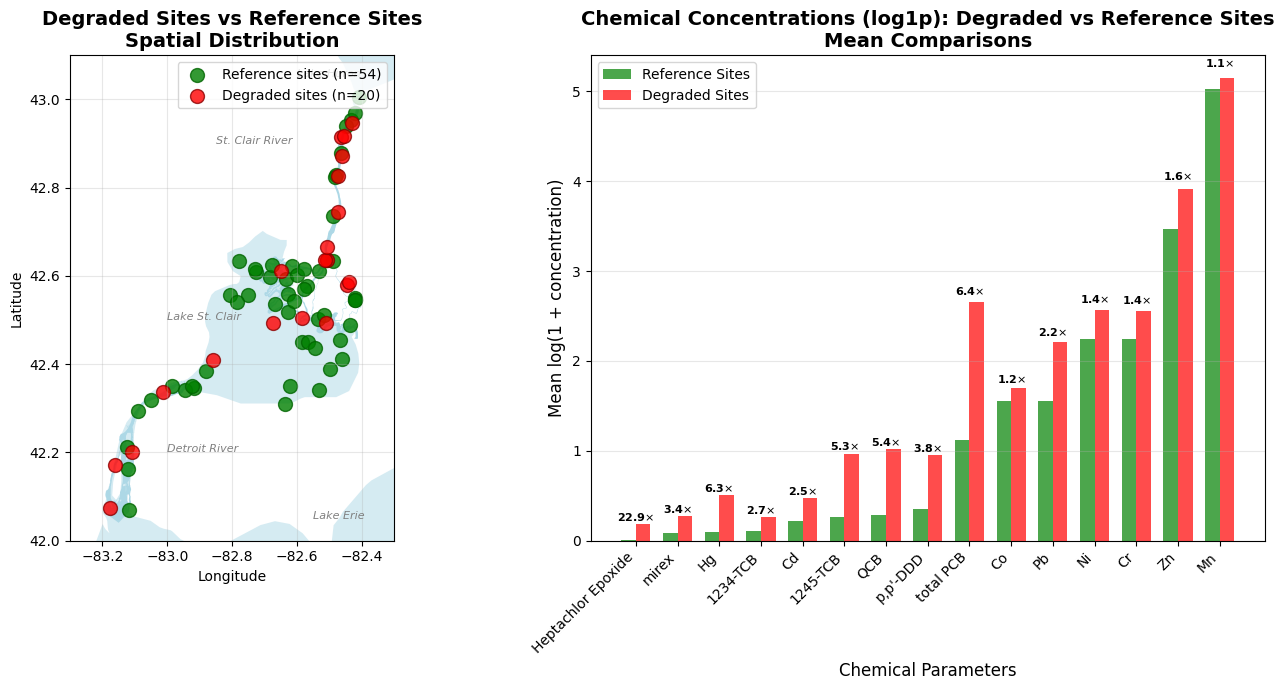


Reference Sites Summary:
Number of sites: 54
Pollution score range: -4.401 to -0.243
Waterbodies represented: {'LSC': 37, 'DR': 9, 'SCR': 8}

Degraded Sites Summary:
Number of sites: 20
Pollution score range: 2.279 to 10.622
Waterbodies represented: {'LSC': 9, 'SCR': 7, 'DR': 4}


In [2807]:
# Create a comprehensive comparison plot of degraded vs reference sites
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Left panel: Spatial distribution showing degraded vs reference sites
plot_rivers_lakes(ax=ax1, annotating=True)

# Plot reference sites in green (background)
ax1.scatter(raw_reference_data['Longitude'], raw_reference_data['Latitude'], 
           c='green', s=100, alpha=0.8, edgecolors='darkgreen', linewidths=1,
           label=f'Reference sites (n={len(raw_reference_data)})')

# Plot degraded sites in red (foreground)
ax1.scatter(raw_deg_data['Longitude'], raw_deg_data['Latitude'], 
           c='red', s=100, alpha=0.8, edgecolors='darkred', linewidths=1,
           label=f'Degraded sites (n={len(raw_deg_data)})')

ax1.set_title('Degraded Sites vs Reference Sites\nSpatial Distribution', 
             fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right panel: Chemical comparison between degraded and reference sites
# Select key chemical columns (excluding biological and coordinate data)
chemical_cols = ['Heptachlor Epoxide', "p,p'-DDD", 'QCB', '1234-TCB', 'Cd', 'Co', 'Cr', 'mirex', 'total PCB', 
                'Hg', 'Mn', 'Ni', 'Pb', 'Zn', '1245-TCB']

# Apply log(1 + x) transformation to concentrations before computing means
ref_log1p = np.log1p(raw_reference_data[chemical_cols])
deg_log1p = np.log1p(raw_deg_data[chemical_cols])

# Calculate means for reference sites and sort by absolute values (ascending)
ref_means_for_sorting = ref_log1p.mean()
chemical_cols = ref_means_for_sorting.abs().sort_values().index.tolist()

# Calculate means for both groups in log1p scale
ref_means = ref_log1p[chemical_cols].mean()
deg_means = deg_log1p[chemical_cols].mean()

# Create comparison DataFrame in log1p scale
comparison_data = pd.DataFrame({
    'Reference Sites (log1p)': ref_means,
    'Degraded Sites (log1p)': deg_means
})

# Create bar plot
x_pos = np.arange(len(chemical_cols))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, comparison_data['Reference Sites (log1p)'], 
               width, label='Reference Sites', color='green', alpha=0.7)
bars2 = ax2.bar(x_pos + width/2, comparison_data['Degraded Sites (log1p)'], 
               width, label='Degraded Sites', color='red', alpha=0.7)

# Customize the plot
ax2.set_xlabel('Chemical Parameters', fontsize=12)
ax2.set_ylabel('Mean log(1 + concentration)', fontsize=12)
ax2.set_title('Chemical Concentrations (log1p): Degraded vs Reference Sites\nMean Comparisons', 
             fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(chemical_cols, rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars for key differences (in log1p scale)
for i, (ref_val, deg_val) in enumerate(zip(comparison_data['Reference Sites (log1p)'], 
                                          comparison_data['Degraded Sites (log1p)'])):
    # Compare on original scale via ratio for interpretability
    ref_orig = np.expm1(ref_val)
    deg_orig = np.expm1(deg_val)
    ratio = deg_orig / ref_orig if ref_orig != 0 else float('inf')
    if ratio > 1 or ratio < 0.5:  # Show label if difference is substantial
        ax2.text(i, max(ref_val, deg_val) * 1.02, f'{ratio:.1f}$\\times$', 
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics in both original and log1p scales
print(f"\nReference Sites Summary:")
print(f"Number of sites: {len(raw_reference_data)}")
print(f"Pollution score range: {raw_reference_data['SumRel'].min():.3f} to {raw_reference_data['SumRel'].max():.3f}")
print(f"Waterbodies represented: {raw_reference_data['Waterbody'].value_counts().to_dict()}")

print(f"\nDegraded Sites Summary:")
print(f"Number of sites: {len(raw_deg_data)}")
print(f"Pollution score range: {raw_deg_data['SumRel'].min():.3f} to {raw_deg_data['SumRel'].max():.3f}")
print(f"Waterbodies represented: {raw_deg_data['Waterbody'].value_counts().to_dict()}")

## Validate the representative of references in environmental-taxa space

In estimating the environmental-taxa relationship, the samples should be representative, randomized chosen from the env-taxa space. 

That is, when setting the least-pollutant constraint, the selected references are confined and worth checking their representativeness for the rest (test) sites.

**References sites vs Test sites** (in env-taxa space)

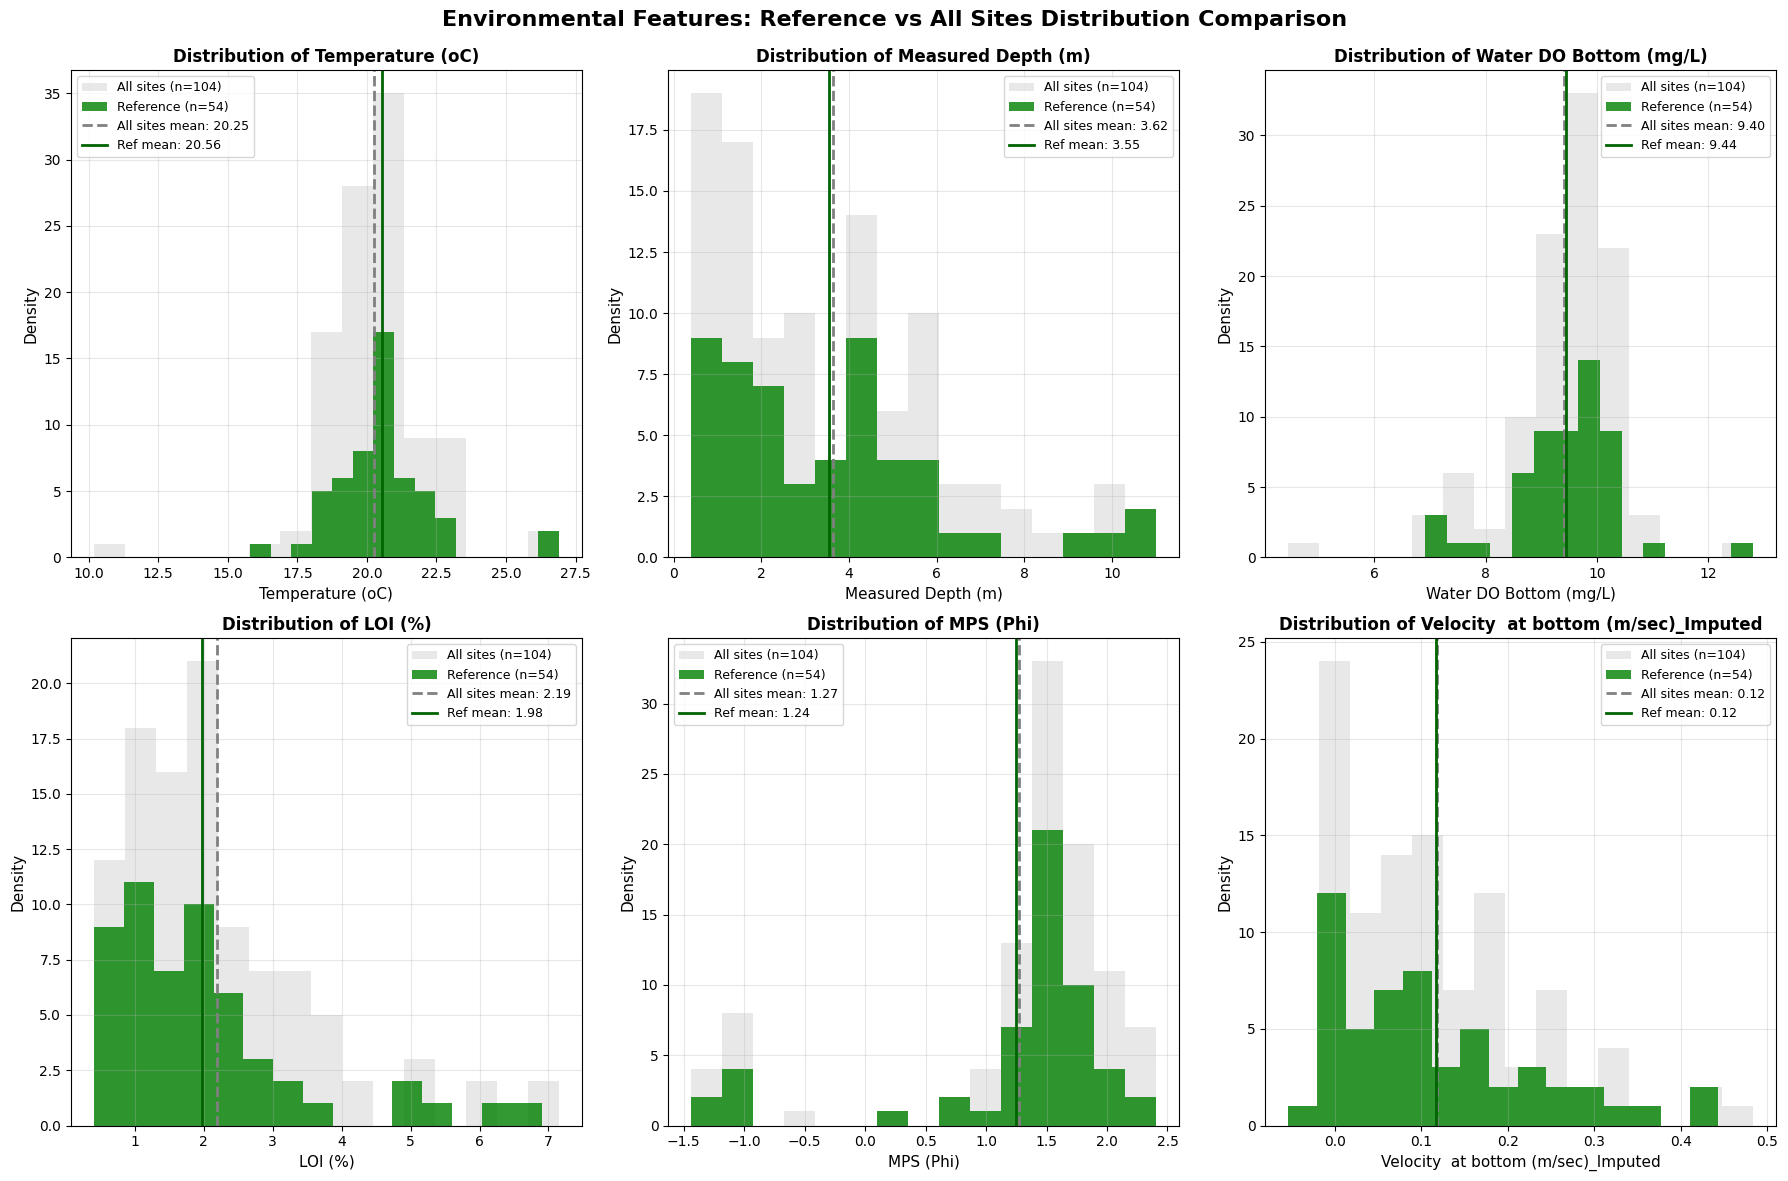

Environmental Features Summary (Reference vs All Sites):
Environmental Features Statistical Comparison (Reference vs All Sites)
Feature                   Ref Mean   Ref Std    All Mean   All Std    T-Stat     P-Value      Sig  
----------------------------------------------------------------------------------------------------
Temperature (oC)          20.557     1.832      20.254     1.927      0.968      0.3354       NS   
Measured Depth (m)        3.552      2.578      3.623      2.600      -0.164     0.8698       NS   
Water DO Bottom (mg/L)    9.442      0.964      9.402      1.057      0.242      0.8095       NS   
LOI (%)                   1.978      1.426      2.188      1.379      -0.886     0.3774       NS   
MPS (Phi)                 1.243      0.938      1.273      0.971      -0.184     0.8544       NS   
Velocity  at bottom (m/sec)_Imputed 0.117      0.117      0.118      0.110      -0.034     0.9728       NS   

Significance levels: *** p<0.001, ** p<0.01, * p<0.05, NS p>

In [2808]:
# compare the distributions of reference and all sites for environmental features
from scipy.stats import ttest_ind

# Select environmental features for analysis (excluding water velocity due to missing data)
env_features = ['Temperature (oC)', 'Measured Depth (m)', 'Water DO Bottom (mg/L)', 'LOI (%)', 'MPS (Phi)', 'Velocity  at bottom (m/sec)_Imputed']

# Create a comprehensive visualization of environmental features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(env_features):
    ax = axes[i]
    
    # Get data for reference and all sites
    ref_data = raw_reference_data[feature].dropna()
    all_data = raw_data[feature].dropna()
    
    # Build consistent bin edges from all-data range
    bins = 15
    # Create histograms: all-sample in background, reference in front
    ax.hist(all_data, bins=bins, alpha=0.5, label=f'All sites (n={len(all_data)})', 
            color='lightgray', density=False)
    ax.hist(ref_data, bins=bins, alpha=0.8, label=f'Reference (n={len(ref_data)})', 
            color='green', density=False)
    
    # Add vertical lines for means
    ax.axvline(all_data.mean(), color='gray', linestyle='--', linewidth=2, 
               label=f'All sites mean: {all_data.mean():.2f}')
    ax.axvline(ref_data.mean(), color='darkgreen', linestyle='-', linewidth=2,
               label=f'Ref mean: {ref_data.mean():.2f}')
    
    # Styling
    ax.set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Add overall title
fig.suptitle('Environmental Features: Reference vs All Sites Distribution Comparison', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

# Print statistical summary
print("Environmental Features Summary (Reference vs All Sites):")
print("=" * 50)
# Create a comprehensive statistics table
stats_table = []

for feature in env_features:
    ref_vals = raw_reference_data[feature].dropna()
    all_vals = raw_data[feature].dropna()
    
    # Perform t-test (reference vs all sites)
    t_stat, p_val = ttest_ind(ref_vals, all_vals, equal_var=False)
    
    # Calculate basic statistics
    ref_mean = ref_vals.mean()
    ref_std = ref_vals.std()
    all_mean = all_vals.mean()
    all_std = all_vals.std()
    
    # Determine significance
    significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "NS"
    
    # Add to table
    stats_table.append({
        'Feature': feature,
        'Ref_Mean': ref_mean,
        'Ref_Std': ref_std,
        'All_Mean': all_mean,
        'All_Std': all_std,
        'T_Stat': t_stat,
        'P_Value': p_val,
        'Significance': significance
    })

# Convert to DataFrame for better formatting
stats_df = pd.DataFrame(stats_table)

# Print formatted table
print("Environmental Features Statistical Comparison (Reference vs All Sites)")
print("=" * 100)
print(f"{'Feature':<25} {'Ref Mean':<10} {'Ref Std':<10} {'All Mean':<10} {'All Std':<10} {'T-Stat':<10} {'P-Value':<12} {'Sig':<5}")
print("-" * 100)

for _, row in stats_df.iterrows():
    print(f"{row['Feature']:<25} {row['Ref_Mean']:<10.3f} {row['Ref_Std']:<10.3f} {row['All_Mean']:<10.3f} {row['All_Std']:<10.3f} {row['T_Stat']:<10.3f} {row['P_Value']:<12.4f} {row['Significance']:<5}")

print("\nSignificance levels: *** p<0.001, ** p<0.01, * p<0.05, NS p>=0.05")
print(f"\nSummary: {len(stats_df[stats_df['Significance'] != 'NS'])} out of {len(stats_df)} features show significant differences")

## Q-Mode (Association Measures): Dissimilarity Matrix on sites of species data

Clustering analysis **implicitly relies on dissimilarity/distance matrix** of the objects to be clustered.
The distance matrix is built upon the **chosen measurements** on objects and the way of computing distance upon it.

Doing clustering analysis on sites with species data needs to consider the ecological meanings of the measures, the raw measures always fails this requirements. Therefore, proper distance matrix needs to be constructed to include the ecological meanings correctly.

The individual taxa abundances are not significantly different across pollution levels (reference vs test sites), as shown in the figure above.

**However,** according to Legendre & Legendre, **pollution impacts multivariate community composition**, not the univariate abundance of individual taxa.

What acutally changes include:
- Relative abundances across taxa (community composition)
- Multivariate structure of the assemblages (species diversity)
- Presence-absence of sensitive vs tolerant taxa

<span style="color:blue">Trap: checking the taxa abundances across reference vs text sites can be confusing and misleading..</span>

What pollution impacts more is the **multivariate community composition**, not the univariate abundance of individual taxa


In [2809]:
# fetch the taxa blocks of references and all sites
taxa_block = get_block(data, "taxa")

# Align taxa for reference and all sites
taxa_ref = taxa_block.loc[reference_data.index]
taxa_all = taxa_block.copy()

# Get non-reference sites as benchmark
non_ref_indices = taxa_all.index.difference(taxa_ref.index)
taxa_non_ref = taxa_all.loc[non_ref_indices]

# Select taxa features for analysis (non-zero variance across all sites)
taxa_features = [col for col in taxa_block.columns if taxa_block[col].var() > 0]

print(f"Number of taxa features considered: {len(taxa_features)}")

Number of taxa features considered: 16


## Asymmetrical Association Measures on sites of species data (address double-zero problem)

According to the book *"Numerical Ecology with R"* by Legendre and Legendre (2019),
the **presence** of a taxon often has a clearer interpretation than its **absence**.
The shared absence at two sites does not contribute to similarity between them, and it raises the so-called **"double-zero problem"**.

Dissimilarity measures made on raw abundance ignores this issue and can lead to ecologically meaningless results.
To address this issue, several transformations (and their corresponding dissimilarity measures) have been proposed: **Bray-Curtis, Chord, Hellinger, Chi-square**.

Take these transformations on species data and the dissimilarity matrix built upon them can effectively solve the double-zero problem.

### Chord normalization

the chord-normalized relative abundance of taxon \(j\) at site \(i\) is:
    
$$
c_{ij} = \frac{p_{ij}}{\sqrt{\sum_{j=1}^{m} p_{ij}^2}}, \quad j = 1, \dots, m
$$

Each site \(i\) is represented as a column vector in the m-dimensional taxa space:

$$
\mathbf{c}_i = \begin{pmatrix} c_{i1} \\ c_{i2} \\ \vdots \\ c_{im} \end{pmatrix}
$$

where the norm of each vector equals 1:

$$
\|\mathbf{c}_i\| = \sqrt{\sum_{j=1}^{m} c_{ij}^2} = 1, \quad i = 1, \dots, n
$$

This places all sites on the unit hypersphere in the m-dimensional taxa space, where Euclidean distances between sites are determined by composition differences (direction) only.

In [2810]:
# define the chord transformation computation function
def chord_transform(df):
    """Apply chord transformation to taxa data of each site."""
    # Calculate the norm of each site's taxa vector (row-wise)
    norm_rows = np.sqrt((df ** 2).sum(axis = 1))
    # Divide each taxa value by the site's norm 
    chord_df = df.div(norm_rows, axis=0)
    return chord_df

# Apply chord transformation to reference and non-reference taxa data
taxa_ref_chord = chord_transform(taxa_ref)
taxa_non_ref_chord = chord_transform(taxa_non_ref)

Compute the distance matrix on chord-normalized data using Euclidean distance, which is called the **Chord distance matrix**.

In [2811]:
# compute the chord distance matrix among reference sites
from sklearn.metrics import pairwise_distances

# Using Euclidean distance on chord-transformed data gives us the chord distance
chord_distance_matrix = pairwise_distances(taxa_ref_chord, metric='euclidean')

# Convert to DataFrame for better visualization with site IDs as labels
chord_distance_df = pd.DataFrame(chord_distance_matrix, 
                                index=taxa_ref_chord.index, 
                                columns=taxa_ref_chord.index)

print("Chord Distance Matrix (Reference Sites):")
print(f"Shape: {chord_distance_df.shape}")
print(f"Distance range: {chord_distance_df.values[chord_distance_df.values > 0].min():.4f} to {chord_distance_df.values.max():.4f}")
print("\nFirst 5x5 subset:")
print(chord_distance_df.iloc[:5, :5].round(4))

Chord Distance Matrix (Reference Sites):
Shape: (54, 54)
Distance range: 0.1135 to 1.3595

First 5x5 subset:
StationID     S96     S93     A66    DCC2     S70
StationID                                        
S96        0.0000  1.0039  0.6168  0.6988  0.4669
S93        1.0039  0.0000  0.9333  0.7112  0.9409
A66        0.6168  0.9333  0.0000  0.5567  0.4419
DCC2       0.6988  0.7112  0.5567  0.0000  0.6016
S70        0.4669  0.9409  0.4419  0.6016  0.0000


### Hellinger normalization

Hellinger normalization is similar to chord normalization, but it takes the square root of each chord-transformed value, which gives higher weight to abundant taxa and less weight to rare taxa.

In [2812]:
# define the hellinger transformation computation function
def hellinger_transform(df):
    """Apply Hellinger transformation to taxa data of each site."""
    # First, calculate relative abundances (same as chord transformation start)
    norm_rows = df.sum(axis = 1)
    chord_df = df.div(norm_rows, axis=0)
    
    # Then take square root of relative abundances
    hellinger_df = np.sqrt(chord_df)
    
    return hellinger_df

# Apply Hellinger transformation to reference and non-reference taxa data
taxa_ref_hellinger = hellinger_transform(taxa_ref)
taxa_non_ref_hellinger = hellinger_transform(taxa_non_ref)

Compute the distance matrix on hellinger-normalized data using Euclidean distance, which is called the **Hellinger distance matrix**.

In [2813]:
# compute the hellinger distance matrix among reference sites
hellinger_distance_matrix = pairwise_distances(taxa_ref_hellinger, metric='euclidean')

# Convert to DataFrame for better visualization with site IDs as labels
hellinger_distance_df = pd.DataFrame(hellinger_distance_matrix, 
                                    index=taxa_ref_hellinger.index, 
                                    columns=taxa_ref_hellinger.index)

print("Hellinger Distance Matrix (Reference Sites):")
print(f"Shape: {hellinger_distance_df.shape}")
print(f"Distance range: {hellinger_distance_df.values[hellinger_distance_df.values > 0].min():.4f} to {hellinger_distance_df.values.max():.4f}")
print("\nFirst 5x5 subset:")
print(hellinger_distance_df.iloc[:5, :5].round(4))

Hellinger Distance Matrix (Reference Sites):
Shape: (54, 54)
Distance range: 0.0553 to 1.2885

First 5x5 subset:
StationID     S96     S93     A66    DCC2     S70
StationID                                        
S96        0.0000  0.9104  0.6962  0.8034  0.6684
S93        0.9104  0.0000  0.7438  0.6274  0.8553
A66        0.6962  0.7438  0.0000  0.5236  0.5580
DCC2       0.8034  0.6274  0.5236  0.0000  0.6659
S70        0.6684  0.8553  0.5580  0.6659  0.0000


### Addition 2: Octave Transformation and Euclidean Distance on species clustering

In [2814]:
# define the Octave transformation computation function
def octave_transform(df):
    """Apply Octave transformation to taxa data of each site."""
    # first sum up all taxa abundances for each site
    total_abundance = df.sum(axis = 1)
    # to individual species abundances, divide by the total abundance to get proportions
    proportion_df = df.div(total_abundance, axis = 0)
    # then apply the log_2(100 * (proportion + 0.01)) tansformation as final Octave values
    octave_df = np.log2(100 * (proportion_df + 0.01))
    return octave_df

# apply Octave transformation to reference and non-reference taxa data
taxa_ref_octave = octave_transform(taxa_ref)
taxa_non_ref_octave = octave_transform(taxa_non_ref)

In [2815]:
# compute the Octave distance (Euclidean) matrix among references
octave_distance_matrix = pairwise_distances(taxa_ref_octave, metric='euclidean')

# Convert to DataFrame for better visualization with site IDs as labels
octave_distance_df = pd.DataFrame(octave_distance_matrix, 
                                    index=taxa_ref_octave.index, 
                                    columns=taxa_ref_octave.index)

print("Octave Distance Matrix (Reference Sites):")
print(f"Shape: {octave_distance_df.shape}")
print(f"Distance range: {octave_distance_df.values[octave_distance_df.values > 0].min():.4f} to {octave_distance_df.values.max():.4f}")
print("\nFirst 5x5 subset:")
print(octave_distance_df.iloc[:5, :5].round(4))

Octave Distance Matrix (Reference Sites):
Shape: (54, 54)
Distance range: 0.2590 to 12.4229

First 5x5 subset:
StationID     S96     S93     A66    DCC2     S70
StationID                                        
S96        0.0000  8.5350  7.0246  8.1793  7.1283
S93        8.5350  0.0000  7.0355  6.3985  8.7746
A66        7.0246  7.0355  0.0000  5.4402  6.1735
DCC2       8.1793  6.3985  5.4402  0.0000  7.1603
S70        7.1283  8.7746  6.1735  7.1603  0.0000


Now try the clustering on Octave transformed data with Euclidean distance matrix.

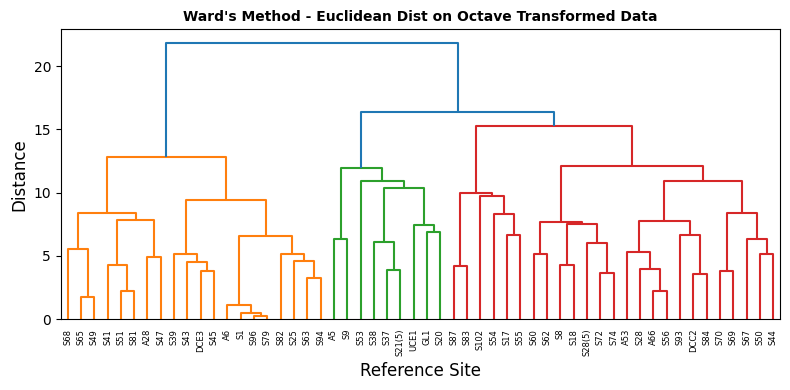

In [2816]:
# make Ward's clustering based on the octave transformed data
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
linkage_matrix = linkage(taxa_ref_octave, method='ward')

# Plot the dendrogram
plt.figure(figsize=(8, 4))
dendrogram(linkage_matrix, labels=taxa_ref_octave.index, leaf_rotation=90)
plt.title("Ward's Method - Euclidean Dist on Octave Transformed Data", fontsize=10, fontweight='bold')
plt.xlabel("Reference Site", fontsize=12)
plt.ylabel("Distance", fontsize=12)
plt.tight_layout()
plt.show()

Try the same Ward's Method on the Hellinger transformed data with Euclidean distance matrix.

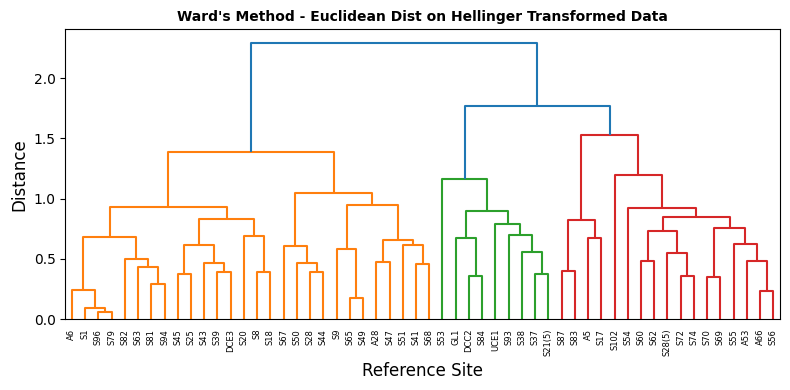

In [2817]:
# make Ward's clustering based on the hellinger transformed data
linkage_matrix = linkage(taxa_ref_hellinger, method='ward')

# Plot the dendrogram
plt.figure(figsize=(8, 4))
dendrogram(linkage_matrix, labels=taxa_ref_hellinger.index, leaf_rotation=90)
plt.title("Ward's Method - Euclidean Dist on Hellinger Transformed Data", fontsize=10, fontweight='bold')
plt.xlabel("Reference Site", fontsize=12)
plt.ylabel("Distance", fontsize=12)
plt.tight_layout()
plt.show()

### Check the spatial and env-feature conditions

Skip the validation of clustering results at the preview stage, subjectively chose k groups as a good typology for some external comparisons

- spatial distribution 
- differences in environmental features

In [2818]:
# apply hierarchical clustering with k clusters using the octave transformed data
from sklearn.cluster import AgglomerativeClustering

preview_k = 3 # number of clusters
preview_linkage = 'ward'
preview_dis_matrix = octave_distance_matrix # a computed distance matrix
preview_tran_data = taxa_ref_hellinger # for ward's clusteirng
# feed them into clustering function
clustering = AgglomerativeClustering(n_clusters=preview_k, linkage=preview_linkage)
cluster_labels = clustering.fit_predict(preview_tran_data)

# Create a DataFrame to map sites to their cluster groups
site_clusters = pd.DataFrame({
    'StationID': taxa_ref_hellinger.index,
    'Cluster_Group': cluster_labels
})

# add the cluster group labels as a subblock to the reference data
reference_data[('Cluster_Group', "asym", "octave_groups")] = site_clusters.set_index('StationID').loc[reference_data.index, 'Cluster_Group']
# add the cluster group labels as a subblock to the raw reference data
raw_reference_data["octave_groups"] = site_clusters.set_index('StationID').loc[raw_reference_data.index, 'Cluster_Group']

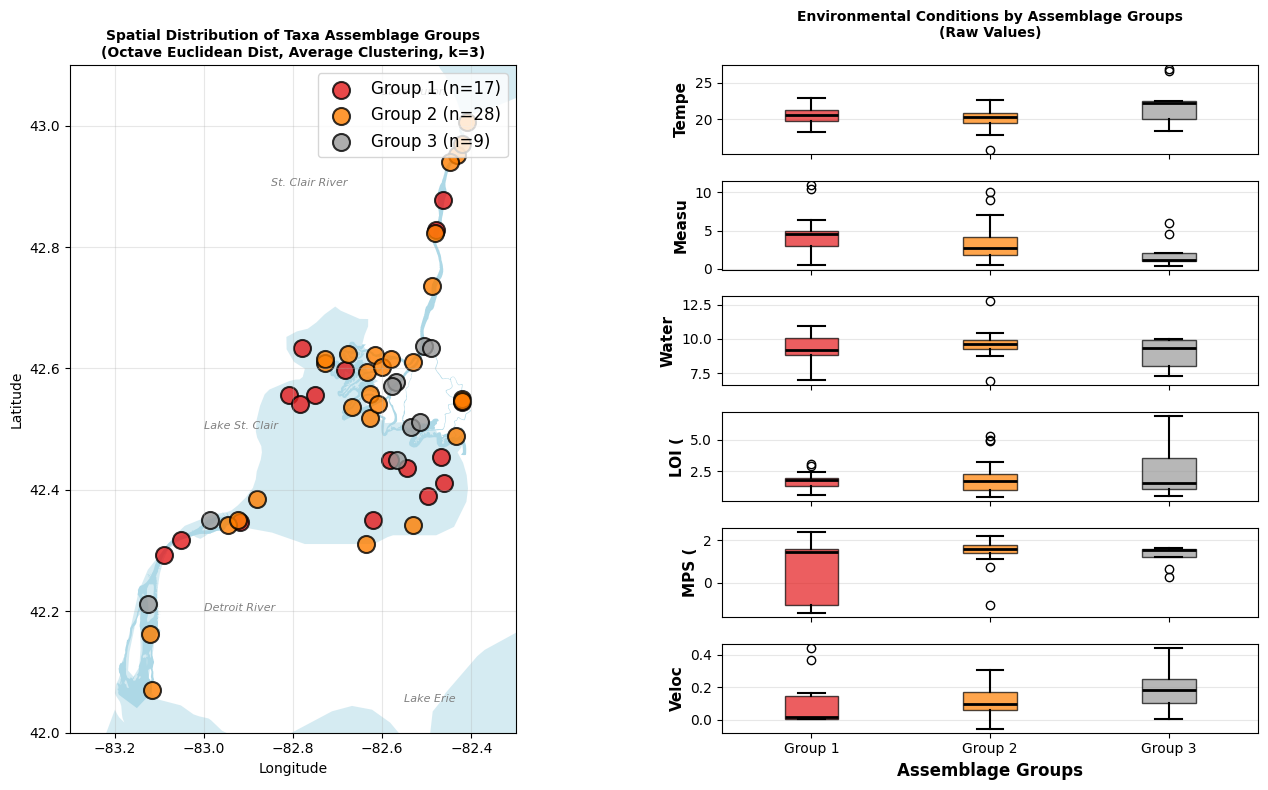

Assemblage Groups Analysis Summary:

Assemblage Groups Summary Table:
Group    N   Sites                     Waterbodies                    Top 3 Dominant Taxa                               
------------------------------------------------------------------------------------------------------------------------
Group 1  17  A66, S70, S54, S72, S7... LSC(12); DR(3); SCR(2)         Oligochaeta(0.394); Dreissena(0.388); Chironomi...
Group 2  28  S96, S51, S65, S41, S6... LSC(18); SCR(6); DR(4)         Oligochaeta(0.579); Chironomidae(0.533); Nemato...
Group 3  9   S93, DCC2, GL1, S53, S... LSC(7); DR(2)                  Oligochaeta(0.473); Chironomidae(0.418); Gastro...

Environmental Conditions Summary (Mean ± Std):
Group     Temperature    Measured Dep   Water DO Bot   LOI            MPS            Velocity  at   
------------------------------------------------------------------------------------------------------------------------
Group 1   20.59±1.40     4.59±2.79      9.36±0.93      

In [2819]:
# visualize the boxplots for the environmental features across the selected groups
fig = plt.figure(figsize=(13, 8))

# Create subplot layout: left panel for map (1/2 width), right panel split into 6 rows for each env variable
ax_map = plt.subplot2grid((6, 2), (0, 0), rowspan=6)  # Map spans full left side

# Left panel: Spatial distribution map
plot_rivers_lakes(ax=ax_map, annotating=True)

colors = plt.cm.Set1(np.linspace(0, 1, preview_k))
cluster_names = [f'Group {i+1}' for i in range(preview_k)]

for cluster_id in range(preview_k):
    cluster_sites = raw_reference_data[raw_reference_data['octave_groups'] == cluster_id]
    
    ax_map.scatter(cluster_sites['Longitude'], cluster_sites['Latitude'], 
               c=[colors[cluster_id]], s=150, alpha=0.8, 
               edgecolors='black', linewidths=1.5,
               label=f'{cluster_names[cluster_id]} (n={len(cluster_sites)})')

ax_map.set_title(f'Spatial Distribution of Taxa Assemblage Groups\n(Octave Euclidean Dist, Average Clustering, k={preview_k})', 
             fontsize=10, fontweight='bold')
ax_map.legend(loc='upper right', fontsize=12)
ax_map.grid(True, alpha=0.3)

# Right panel: Environmental variables boxplots (6 separate axes for each variable)
env_features_selected = ['Temperature (oC)', 'Measured Depth (m)', 'Water DO Bottom (mg/L)', 
                        'LOI (%)', 'MPS (Phi)', 'Velocity  at bottom (m/sec)_Imputed']

# Create 6 subplots on the right side (one for each environmental feature)
env_axes = []
for i in range(6):
    ax_env = plt.subplot2grid((6, 2), (i, 1))
    env_axes.append(ax_env)

# Prepare data for boxplots
for idx, (ax_env, feature) in enumerate(zip(env_axes, env_features_selected)):
    # Collect data for each group
    data_by_group = []
    for cluster_id in range(preview_k):
        cluster_indices = raw_reference_data[raw_reference_data['octave_groups'] == cluster_id].index
        group_data = raw_reference_data.loc[cluster_indices, feature].dropna()
        data_by_group.append(group_data)
    
    # Create boxplot
    bp = ax_env.boxplot(data_by_group, tick_labels=cluster_names, patch_artist=True,
                        boxprops=dict(alpha=0.7),
                        medianprops=dict(color='black', linewidth=2),
                        whiskerprops=dict(linewidth=1.5),
                        capprops=dict(linewidth=1.5))
    
    # Color the boxes according to cluster colors
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Styling
    ax_env.set_ylabel(feature[:5], fontsize=11, fontweight='bold')
    ax_env.grid(True, alpha=0.3, axis='y')
    ax_env.tick_params(axis='x', labelsize=10)
    ax_env.tick_params(axis='y', labelsize=10)
    
    # Only show x-label on bottom plot
    if idx == len(env_features_selected) - 1:
        ax_env.set_xlabel('Assemblage Groups', fontsize=12, fontweight='bold')
    else:
        ax_env.set_xticklabels([])

# Add overall title for right panel
env_axes[0].set_title('Environmental Conditions by Assemblage Groups\n(Raw Values)', 
                     fontsize=10, fontweight='bold', pad=20)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

# Print summary statistics
print("Assemblage Groups Analysis Summary:")
print("=" * 50)
# Collect taxa data for summary
group_means_taxa = []
for cluster_id in range(preview_k):
    cluster_indices = raw_reference_data[raw_reference_data['octave_groups'] == cluster_id].index
    group_taxa_data = taxa_ref_hellinger.loc[cluster_indices]
    group_mean = group_taxa_data.mean()
    group_means_taxa.append(group_mean)

# Create summary table
summary_data = []
for cluster_id in range(preview_k):
    cluster_sites = raw_reference_data[raw_reference_data['octave_groups'] == cluster_id]
    
    # Basic group info
    group_info = {
        'Group': cluster_names[cluster_id],
        'Sites_Count': len(cluster_sites),
        'Sites': ', '.join(map(str, cluster_sites.index.tolist())),
        'Waterbodies': '; '.join([f"{wb}({count})" for wb, count in cluster_sites['Waterbody'].value_counts().items()])
    }
    
    # Top 3 dominant taxa
    cluster_taxa_means = group_means_taxa[cluster_id].sort_values(ascending=False)
    top_taxa = cluster_taxa_means.head(3)
    group_info['Top_3_Taxa'] = '; '.join([f"{taxa}({val:.3f})" for taxa, val in top_taxa.items()])
    
    # Environmental conditions
    for feature in env_features_selected:
        feature_data = cluster_sites[feature].dropna()
        group_info[f'{feature}_Mean'] = feature_data.mean()
        group_info[f'{feature}_Std'] = feature_data.std()
    
    summary_data.append(group_info)

# Convert to DataFrame for better display
summary_df = pd.DataFrame(summary_data)

print("\nAssemblage Groups Summary Table:")
print("=" * 120)
print(f"{'Group':<8} {'N':<3} {'Sites':<25} {'Waterbodies':<30} {'Top 3 Dominant Taxa':<50}")
print("-" * 120)

for _, row in summary_df.iterrows():
    sites_short = row['Sites'][:22] + "..." if len(row['Sites']) > 25 else row['Sites']
    wb_short = row['Waterbodies'][:27] + "..." if len(row['Waterbodies']) > 30 else row['Waterbodies']
    taxa_short = row['Top_3_Taxa'][:47] + "..." if len(row['Top_3_Taxa']) > 50 else row['Top_3_Taxa']
    
    print(f"{row['Group']:<8} {row['Sites_Count']:<3} {sites_short:<25} {wb_short:<30} {taxa_short:<50}")

print("\nEnvironmental Conditions Summary (Mean ± Std):")
print("=" * 120)
env_header = f"{'Group':<10}"
for feature in env_features_selected:
    short_name = feature.split('(')[0].strip()[:12]
    env_header += f"{short_name:<15}"
print(env_header)
print("-" * 120)

for _, row in summary_df.iterrows():
    env_line = f"{row['Group']:<10}"
    for feature in env_features_selected:
        mean_val = row[f'{feature}_Mean']
        std_val = row[f'{feature}_Std']
        env_line += f"{mean_val:.2f}±{std_val:.2f}"[:14].ljust(15)
    print(env_line)

## Deciding a Good Typology for Hierarchical Clustering Results

Typology refers to a bunch of decisions/results that derive from hierarchical clustering analysis on the taxa data.

A good typology should have **a well representative (retains dissimilarity structure) cutting level** and
**good ecological interpretability**, both built upon a **meaningful clustering algorithm and dissimilarity measure**.

### Three aspects of specific computation to decide a good typology. 

**1. Choose dissimilarity measure and clustering algorithm**
- The dissimilarity measure (Bray–Curtis, Hellinger–Euclidean, Chord)
- The clustering algorithm (hierarchical)
- The linkage method: single, complete, average, ward
- Method:
  - (a) cophenetic correlation analysis

**2. Choose a cut level (Internal validation)**
- How many groups want to be formed
- How good the cut level retains the original dissimilarity structure
  - (a) fusion-level plots


**3. Provide an ecological interpretation (External validation)**
- Define what those clusters mean in various real ecological interpretations.
- Connects the clusters with ecological interpretation with:
  - (a) species composition
  - (b) the habitat conditions; 
  - (c) environmental processes

### Choose the dissimilarity measure and clustering algorithm

- **Dissimilarity measure: Hellinger distance**

    Backed up by the book and limited evidence, we choose **Hellinger distance** as the asymmetrical association measure to enter the later hierarchical clustering analysis.

- **Clustering algorithm: Hierarchical clustering with Ward's linkage**

    Based on the Hellinger distance matrix, apply hierarchcal clustering with 4 linkage methods: single, complete, average, ward.

    Use cophenetic correlation analysis to check which one retains the original dissimilarity structure best.

    <span style="color:blue">However, Ward's linkage is favored here disregarding the cophenetic correlation</span>
    because Ward's method provides a more balanced cluster sizes that we can train **Linear Discriminant Analysis (LDA)** models on.

    <span style="color:blue">This unimpeded choice of Ward's linkage may change with more data set coming later.</span>

Cophenetic correlation analysis for 4 linkages with Hellinger distance matrix

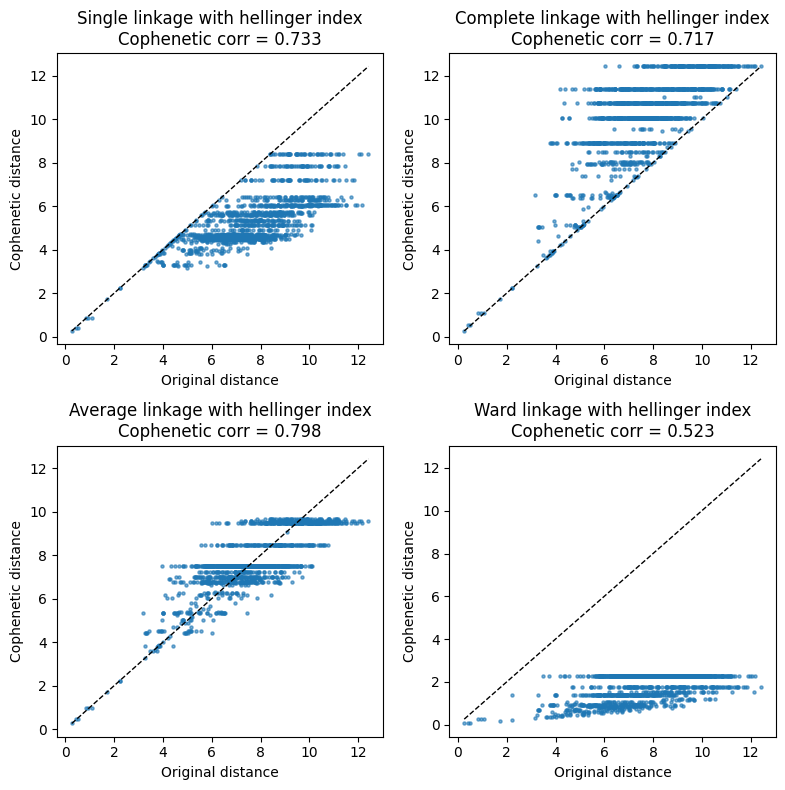

In [2820]:
# try the Cophenetic Correlation to compare different linkage methods
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, cophenet
import matplotlib.pyplot as plt

# Compute condensed distance matrix directly from transformed data
# This is more reliable than converting from square form
D_condensed = pdist(taxa_ref_octave, metric='euclidean')

methods = ["single", "complete", "average", "ward"]
coph_corrs = {}

fig, axs = plt.subplots(2, 2, figsize=(8, 8))
axs = axs.ravel()

for ax, method in zip(axs, methods):
    # seperate the feeded data for ward's method
    if method == "ward":
        Z = linkage(taxa_ref_hellinger, method=method)
    else:
        Z = linkage(D_condensed, method=method)
    coph_corr, coph_dists = cophenet(Z, D_condensed)  # Note: returns (correlation, cophenetic distances)
    coph_corrs[method] = coph_corr

    ax.scatter(D_condensed, coph_dists, s=5, alpha=0.6)
    ax.plot([D_condensed.min(), D_condensed.max()], [D_condensed.min(), D_condensed.max()], "k--", linewidth=1)
    ax.set_title(f"{method.capitalize()} linkage with hellinger index\n"
                 f"Cophenetic corr = {coph_corr:.3f}")
    ax.set_xlabel("Original distance")
    ax.set_ylabel("Cophenetic distance")

plt.tight_layout()
plt.show()

### Choose a cutting level (Internal validation)

Use fusion-level plots to visualize how clusters are formed at each merge step and decide a good cutting level.

Fusion-level plots for 4 linkages with Hellinger distance matrix. 

Each fusion-level plot is read from top left to bottom right.
A node shows the group number at each merge step (x-axis: fusion height; y-axis: group number),
the **segment/plateau** to its right indicates the linkage distance used to merge two clusters at that step.

To read a fusion-level plot:

**The longer the plateau $\rightarrow$ the longer distant the two clusters to be merged $\rightarrow$ the more distinct/stable the current clusters are $\rightarrow$ the better the cut level is**

Therefore, listing wanted numbers of clusters and checking their fusion heights (node heights/linkage distances) can help decide a good cut level (specific number of clusters).

In [2821]:
# define the fusion plot function as R in the book
def fusion_plot(Z, method_name, transformation_method="Octave"):
    """
    Plot fusion levels as a step plot showing how many clusters remain at each node height.
    
    Parameters:
    -----------
    Z : ndarray
        Linkage matrix from hierarchical clustering
    method_name : str
        Name of the linkage method (e.g., 'complete', 'ward')
    transformation_method : str
        Name of the distance measure (e.g., 'Octave', 'Hellinger')
    """
    n = Z.shape[0] + 1  # number of original observations
    heights = Z[:, 2]   # fusion heights
    
    # k goes from n down to 1 as we merge clusters
    k_vals = np.arange(n, 0, -1)
    
    # Create extended arrays for step plot
    # Start with n clusters at height 0, then decrease as we merge
    h_extended = np.concatenate([[0], heights])
    k_extended = k_vals
    
    # Plot as step function (post style keeps horizontal line then drops)
    plt.step(h_extended, k_extended, where='post', linewidth=1.5, color='red')
    
    # Add markers at fusion points
    plt.plot(heights, k_vals[1:], 'o', markersize=4, color='red', alpha=0.7)
    
    # Add text labels for selected k values
    label_positions = [n, n//2, n//4, 5, 3, 2]
    for k in label_positions:
        if k <= n and k >= 1:
            idx = n - k
            if idx < len(heights):
                h = heights[idx] if idx > 0 else 0
                plt.text(h, k, str(k), fontsize=8, ha='left', va='center', 
                        color='red', fontweight='normal')
    
    plt.xlabel("h (node height)", fontsize=10)
    plt.ylabel("k (number of clusters)", fontsize=10)
    plt.title(f"Fusion levels - {method_name.capitalize()}; Euclidean on {transformation_method} trans", 
             fontsize=11, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Highlight ward method with yellow background if applicable
    if method_name.lower() == 'ward':
        plt.gca().set_facecolor('#ffffcc')

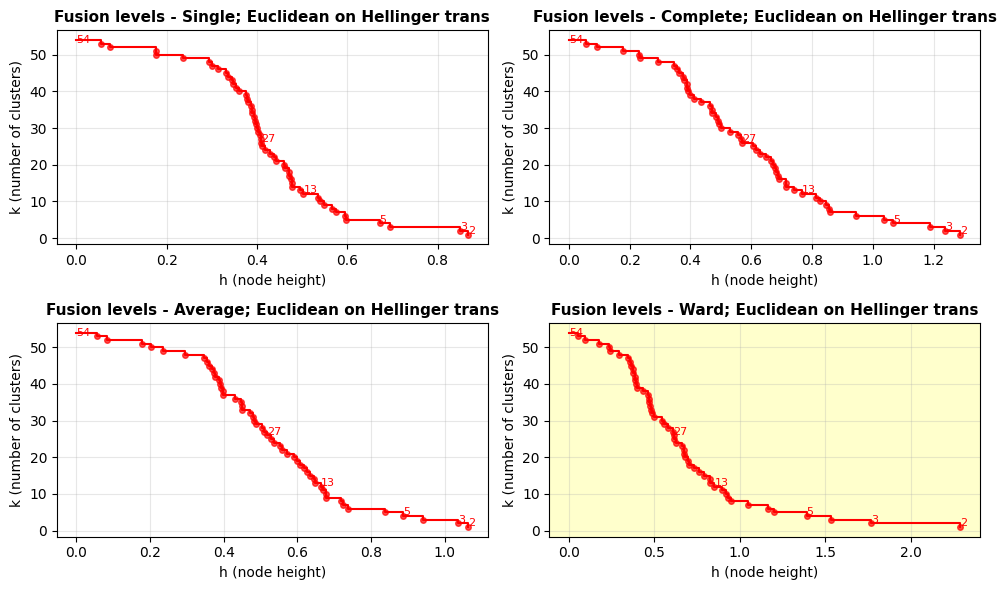

In [2822]:
# plot the fusion levels for the four linkage functions
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
axs = axs.ravel()

for ax, method in zip(axs, methods):
    plt.sca(ax)
    Z = linkage(taxa_ref_hellinger, method=method)
    fusion_plot(Z, method, transformation_method="Hellinger")

plt.tight_layout()
plt.show()

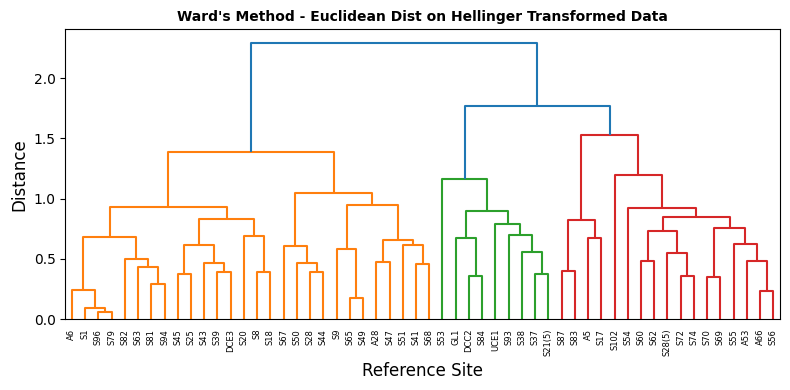

In [2823]:
# view the dendrogram of Ward's clustering based on the octave transformed data
linkage_matrix = linkage(taxa_ref_hellinger, method='ward')

# Plot the dendrogram
plt.figure(figsize=(8, 4))
dendrogram(linkage_matrix, labels=taxa_ref_hellinger.index, leaf_rotation=90)
plt.title("Ward's Method - Euclidean Dist on Hellinger Transformed Data", fontsize=10, fontweight='bold')
plt.xlabel("Reference Site", fontsize=12)
plt.ylabel("Distance", fontsize=12)
plt.tight_layout()
plt.show()

## Provide an ecological interpretation (External validation)

This is the final step to decide a typology: consider the ecological interpretability of the groups.

From another point of view, the clusters obtained from the community composition data can be considered as a factor, or classification criterion, in the ANOVA sense **(Numerical Ecology with R, Legendre & Legendre, 2019)**. 

Under this view, it is good **to perform assessments of ANOVA assumptions** on the habitat features across the clusters and **apply ANOVA if assumptions are met**.

In the ecological interpretation, despite the clustering results act as explanatory factors in the ANOVA, ecologically speaking we really look for an **environmental interpretation of the groups** of sites **(Numerical Ecology with R, Legendre & Legendre, 2019)**, **it validates clusters statistically - not how ecological processes truly work.**

(Confronting the clustering results (considering as response data) with external, independent explanatory data could be done by discriminant analysis(Numerical Ecology with R, Legendre & Legendre, 2019).)

#### Check the ANOVA assumptions across the groups

Given the chosen 4 groups from Ward's hierarchical clustering on Hellinger distance matrix, check the ANOVA assumptions on the habitat features across the groups.

To a habitat feature $x$, it should meet the following assumptions of its uncertainty across (factor) levels:

- **Normality of residuals**: environmental variable values in each cluster should be roughly normal
  
- **Homogeneity of variance (homoscedasticity)**: groups should have similar variances
  
- **Independence**: observations (sites) should be independent

In [2824]:
# apply the final clustering with cutting level (n_groups) from the fusion plot
from sklearn.cluster import AgglomerativeClustering

n_groups = preview_k # number of clusters
preview_linkage = 'ward'
preview_dis_matrix = octave_distance_matrix # a computed distance matrix
preview_tran_data = taxa_ref_hellinger # for ward's clusteirng
# feed them into clustering function
clustering = AgglomerativeClustering(n_clusters=n_groups, linkage=preview_linkage)
cluster_labels = clustering.fit_predict(preview_tran_data)

# Create a DataFrame to map sites to their cluster groups
site_clusters = pd.DataFrame({
    'StationID': taxa_ref_hellinger.index,
    'Cluster_Group': cluster_labels
})

# add the cluster group labels as a subblock to the reference data
reference_data[('Cluster_Group', "asym", "octave_groups")] = site_clusters.set_index('StationID').loc[reference_data.index, 'Cluster_Group']
# add the cluster group labels as a subblock to the raw reference data
raw_reference_data["octave_groups"] = site_clusters.set_index('StationID').loc[raw_reference_data.index, 'Cluster_Group']

In [2825]:
# Assessment of ANOVA assumptions across habitat features and cluster groups
from scipy import stats
from scipy.stats import levene, shapiro, anderson

# Select environmental features for ANOVA assumption testing
env_features_anova = ['Temperature (oC)', 'Measured Depth (m)', 'Water DO Bottom (mg/L)', 
                      'LOI (%)', 'MPS (Phi)', 'Velocity  at bottom (m/sec)_Imputed']

# Get the cluster groups from previous analysis (using k=4 Ward's clustering on Octave)
cluster_groups = raw_reference_data['octave_groups']
n_groups = n_groups # consistent with the k in previous computing

# Store results for summary
assumption_results = []

for feature in env_features_anova:
    # Get data by group
    groups_data = []
    for group_id in range(n_groups):
        group_values = raw_reference_data[raw_reference_data['octave_groups'] == group_id][feature].dropna()
        groups_data.append(group_values)
    
    # Overall data
    all_values = raw_reference_data[feature].dropna()
    
    # Fit ANOVA model to get residuals
    group_means = [group.mean() for group in groups_data]
    residuals = []
    
    for group_id, group_data in enumerate(groups_data):
        group_residuals = group_data - group_means[group_id]
        residuals.extend(group_residuals)
    
    residuals = np.array(residuals)
    
    # Shapiro-Wilk test on residuals
    if len(residuals) >= 3:
        shapiro_stat, shapiro_p = shapiro(residuals)
        normality_pass = shapiro_p > 0.05
    else:
        shapiro_stat, shapiro_p = np.nan, np.nan
        normality_pass = False
    
    # Anderson-Darling test on residuals
    anderson_result = anderson(residuals, dist='norm')
    
    # Check normality for each group
    group_normality = []
    for group_id, group_data in enumerate(groups_data):
        if len(group_data) >= 3:
            sw_stat, sw_p = shapiro(group_data)
            group_normality.append(sw_p > 0.05)
            status = "✓" if sw_p > 0.05 else "✗"
        else:
            group_normality.append(False)
    
    # ========================================
    # 2. HOMOGENEITY OF VARIANCE (Levene's test)
    # ========================================
    # Levene's test
    levene_stat, levene_p = levene(*groups_data)
    if levene_p > 0.05:
        variance_pass = True
    else:
        variance_pass = False
    
    # Store results
    assumption_results.append({
        'Feature': feature,
        'Shapiro_W': shapiro_stat,
        'Shapiro_p': shapiro_p,
        'Normality_Pass': normality_pass,
        'Levene_Stat': levene_stat,
        'Levene_p': levene_p,
        'Variance_Pass': variance_pass,
        'All_Assumptions_Pass': normality_pass and variance_pass
    })
    
# Create compact table output for results
results_df = pd.DataFrame(assumption_results)

# Table 1: Test Statistics
print("\n┌─ ANOVA Assumption Test Statistics (Raw Habitat Features) ─" + "─" * 60 + "┐")
print("│")
print("│  Feature                     │  Shapiro-W │  Shapiro-p │  Levene   │  Levene-p │  Pass  │")
print("│" + "─" * 30 + "┼" + "─" * 12 + "┼" + "─" * 12 + "┼" + "─" * 11 + "┼" + "─" * 11 + "┼" + "─" * 8 + "│")

for _, row in results_df.iterrows():
    feature_short = row['Feature'][:27] + '...' if len(row['Feature']) > 27 else row['Feature']
    pass_mark = "✓" if row['All_Assumptions_Pass'] else "✗"
    print(f"│  {feature_short:<28} │  {row['Shapiro_W']:>8.4f}  │  {row['Shapiro_p']:>8.4f}  │  {row['Levene_Stat']:>7.4f}  │  {row['Levene_p']:>7.4f}  │  {pass_mark:^6} │")

print("│")
print("└" + "─" * 118 + "┘")

# Table 2: Summary Statistics
n_pass_normality = results_df['Normality_Pass'].sum()
n_pass_homogeneity = results_df['Variance_Pass'].sum()
n_pass_overall = results_df['All_Assumptions_Pass'].sum()
n_total = len(results_df)

print("\n┌─ Summary of Assumption Test Results ─┐")
print("│")
print(f"│  Normality passed:     {n_pass_normality}/{n_total}            │")
print(f"│  Homogeneity passed:   {n_pass_homogeneity}/{n_total}            │")
print(f"│  All assumptions met:  {n_pass_overall}/{n_total}            │")
print("│")
print("└" + "─" * 39 + "┘")



┌─ ANOVA Assumption Test Statistics (Raw Habitat Features) ─────────────────────────────────────────────────────────────┐
│
│  Feature                     │  Shapiro-W │  Shapiro-p │  Levene   │  Levene-p │  Pass  │
│──────────────────────────────┼────────────┼────────────┼───────────┼───────────┼────────│
│  Temperature (oC)             │    0.9538  │    0.0364  │   4.8516  │   0.0118  │    ✗    │
│  Measured Depth (m)           │    0.9104  │    0.0007  │   0.4406  │   0.6460  │    ✗    │
│  Water DO Bottom (mg/L)       │    0.9420  │    0.0113  │   1.1853  │   0.3139  │    ✗    │
│  LOI (%)                      │    0.8865  │    0.0001  │   3.9509  │   0.0254  │    ✗    │
│  MPS (Phi)                    │    0.8571  │    0.0000  │   4.1807  │   0.0208  │    ✗    │
│  Velocity  at bottom (m/sec)... │    0.9157  │    0.0010  │   0.8000  │   0.4549  │    ✗    │
│
└──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌

#### Box-Cox transformation to the environmental features and check ANOVA assumptions again

Some raw habitat features do not meet the ANOVA assumptions well, especially the normality of residuals and homogeneity of variance.

Do some transformations (e.g., box-cox method) on the features to stabilize variance and distort the distribution then check the ANOVA assumptions again.

In [2826]:
# apply Box-Cox transformation to habitat features to meet ANOVA assumptions
# Box-Cox finds optimal lambda parameter to normalize the data
from scipy.stats import boxcox
from scipy.special import inv_boxcox

# First, fetch the raw habitat feature data
for feature in env_features_anova:
    feature_data = raw_reference_data[feature].dropna()

print("\n" + "=" * 80)
print("Box-Cox Transformation Analysis")
print("=" * 80)

# Store Box-Cox transformed features and their lambda values
boxcox_features = {}
lambda_values = {}

for feature in env_features_anova:
    feature_data = raw_reference_data[feature].dropna()
    
    # Box-Cox requires all positive values
    # Shift the data if there are negative values or zeros
    if feature_data.min() <= 0:
        shift_value = abs(feature_data.min()) + 1
        shifted_data = feature_data + shift_value
        print(f"\n{feature}:")
        print(f"  - Contains non-positive values (min={feature_data.min():.3f})")
        print(f"  - Shifting by {shift_value:.3f} before Box-Cox transformation")

    else:
        shifted_data = feature_data
        shift_value = 0
        print(f"\n{feature}:")
        print(f"  - All values positive, no shifting needed")
    
    # Apply Box-Cox transformation and find optimal lambda
    try:
        transformed_data, optimal_lambda = boxcox(shifted_data)
        
        # Interpret lambda value
        if abs(optimal_lambda - 1.0) < 0.1:
            interpretation = "≈ No transformation needed"
        elif abs(optimal_lambda - 0.5) < 0.1:
            interpretation = "≈ Square root transformation"
        elif abs(optimal_lambda) < 0.1:
            interpretation = "≈ Log transformation"
        elif abs(optimal_lambda - (-1.0)) < 0.1:
            interpretation = "≈ Reciprocal transformation"
        else:
            interpretation = "Custom power transformation"

        # Create a Series with the same index as the original feature data
        transformed_series = pd.Series(transformed_data, index=feature_data.index)
        
        boxcox_features[feature] = {
            'data': transformed_series,
            'lambda': optimal_lambda,
            'shift': shift_value,
            'interpretation': interpretation
        }
        lambda_values[feature] = optimal_lambda
        
    except Exception as e:
        # Fall back to log transformation
        if shift_value > 0:
            transformed_data = np.log(shifted_data)
        else:
            transformed_data = np.log1p(feature_data)
        transformed_series = pd.Series(transformed_data, index=feature_data.index)
        boxcox_features[feature] = {
            'data': transformed_series,
            'lambda': 0.0,  # log transformation
            'shift': shift_value,
            'interpretation': "Log transformation (fallback)"
        }
        lambda_values[feature] = 0.0

# Add Box-Cox transformed features to raw_reference_data
print("\n" + "=" * 80)
print("Box-Cox Transformed Features Added to Dataset:")
print("=" * 80)
for feature in env_features_anova:
    transform_name = f'{feature}_boxcox_transformed'
    raw_reference_data[transform_name] = boxcox_features[feature]['data']
    lambda_val = boxcox_features[feature]['lambda']
    shift_val = boxcox_features[feature]['shift']
    interp = boxcox_features[feature]['interpretation']
    print(f"Added: {transform_name}")

print("\n✓ Box-Cox transformation completed for all habitat features")


Box-Cox Transformation Analysis

Temperature (oC):
  - All values positive, no shifting needed

Measured Depth (m):
  - All values positive, no shifting needed

Water DO Bottom (mg/L):
  - All values positive, no shifting needed

LOI (%):
  - All values positive, no shifting needed

MPS (Phi):
  - Contains non-positive values (min=-1.437)
  - Shifting by 2.437 before Box-Cox transformation

Velocity  at bottom (m/sec)_Imputed:
  - Contains non-positive values (min=-0.054)
  - Shifting by 1.054 before Box-Cox transformation

Box-Cox Transformed Features Added to Dataset:
Added: Temperature (oC)_boxcox_transformed
Added: Measured Depth (m)_boxcox_transformed
Added: Water DO Bottom (mg/L)_boxcox_transformed
Added: LOI (%)_boxcox_transformed
Added: MPS (Phi)_boxcox_transformed
Added: Velocity  at bottom (m/sec)_Imputed_boxcox_transformed

✓ Box-Cox transformation completed for all habitat features


In [2827]:
# re-run ANOVA assumptions assessment on Box-Cox transformed features
from scipy import stats
from scipy.stats import levene, shapiro, anderson

# List of Box-Cox transformed features
env_features_boxcox = [f'{feature}_boxcox_transformed' for feature in env_features_anova]

# Store results for summary
assumption_results_boxcox = []

for idx, feature_boxcox in enumerate(env_features_boxcox):
    original_feature = env_features_anova[idx]
    lambda_val = boxcox_features[original_feature]['lambda']
    
    # Get data by group
    groups_data = []
    for group_id in range(n_groups):
        group_values = raw_reference_data[raw_reference_data['octave_groups'] == group_id][feature_boxcox].dropna()
        groups_data.append(group_values)
    
    # Overall data
    all_values = raw_reference_data[feature_boxcox].dropna()
    
    # Fit ANOVA model to get residuals
    group_means = [group.mean() for group in groups_data]
    residuals = []
    
    for group_id, group_data in enumerate(groups_data):
        group_residuals = group_data - group_means[group_id]
        residuals.extend(group_residuals)
    
    residuals = np.array(residuals)
    
    # Shapiro-Wilk test on residuals
    if len(residuals) >= 3:
        shapiro_stat, shapiro_p = shapiro(residuals)
        normality_pass = shapiro_p > 0.05
    else:
        shapiro_stat, shapiro_p = np.nan, np.nan
        normality_pass = False
    
    # Levene's test
    levene_stat, levene_p = levene(*groups_data)
    variance_pass = levene_p > 0.05
    
    # Store results
    assumption_results_boxcox.append({
        'Feature': original_feature,
        'Transformed_Feature': feature_boxcox,
        'Lambda': lambda_val,
        'Shapiro_W': shapiro_stat,
        'Shapiro_p': shapiro_p,
        'Normality_Pass': normality_pass,
        'Levene_Stat': levene_stat,
        'Levene_p': levene_p,
        'Variance_Pass': variance_pass,
        'All_Assumptions_Pass': normality_pass and variance_pass
    })

In [2850]:
# display the assessment summary in tabular format
# ==========================================

# Create DataFrames
results_boxcox_df = pd.DataFrame(assumption_results_boxcox)
results_original_df = pd.DataFrame(assumption_results)

print("\n\n")
print("=" * 130)
print("BOX-COX TRANSFORMATION ANALYSIS RESULTS")
print("=" * 130)

# Table 1: Lambda Values and Transformations
print("\n┌─ TABLE 1: Optimal Lambda Values and Transformation Types ─────────────────────────────────────┐")
print(f"│ {'Feature':<25} │ {'Lambda (λ)':<12} │ {'Shift':<8} │ {'Transformation Type':<35} │")
print("├" + "─" * 26 + "┼" + "─" * 14 + "┼" + "─" * 10 + "┼" + "─" * 37 + "┤")
for result in assumption_results_boxcox:
    feature = result['Feature'][:25]
    lambda_val = result['Lambda']
    shift = boxcox_features[result['Feature']]['shift']
    interp = boxcox_features[result['Feature']]['interpretation'][:35]
    print(f"│ {feature:<25} │ {lambda_val:>12.4f} │ {shift:>8.2f} │ {interp:<35} │")
print("└" + "─" * 26 + "┴" + "─" * 14 + "┴" + "─" * 10 + "┴" + "─" * 37 + "┘")

# Table 2: Detailed Test Statistics
print("\n┌─ TABLE 2: ANOVA Assumption Test Statistics ───────────────────────────────────────────────────┐")
print(f"│ {'Feature':<25} │ {'Shapiro-W':<10} │ {'p-value':<9} │ {'Levene':<10} │ {'p-value':<9} │ {'Pass':<5} │")
print("├" + "─" * 26 + "┼" + "─" * 12 + "┼" + "─" * 11 + "┼" + "─" * 12 + "┼" + "─" * 11 + "┼" + "─" * 7 + "┤")
for _, row in results_boxcox_df.iterrows():
    feature = row['Feature'][:25]
    shapiro_w = row['Shapiro_W']
    shapiro_p = row['Shapiro_p']
    levene_stat = row['Levene_Stat']
    levene_p = row['Levene_p']
    pass_status = "✓ Yes" if row['All_Assumptions_Pass'] else "✗ No"
    print(f"│ {feature:<25} │ {shapiro_w:>10.3f} │ {shapiro_p:>9.3f} │ {levene_stat:>10.3f} │ {levene_p:>9.3f} │ {pass_status:<5} │")
print("└" + "─" * 26 + "┴" + "─" * 12 + "┴" + "─" * 11 + "┴" + "─" * 12 + "┴" + "─" * 11 + "┴" + "─" * 7 + "┘")

# Table 3: Comparison Summary
print("\n┌─ TABLE 3: Comparison Summary (Original vs Box-Cox) ───────────────────────────────────────────┐")
print(f"│ {'Feature':<25} │ {'Original':<15} │ {'Box-Cox':<15} │ {'Status':<12} │")
print(f"│ {'':>25} │ {'N   V  All':<15} │ {'N   V  All':<15} │ {'':>12} │")
print("├" + "─" * 26 + "┼" + "─" * 17 + "┼" + "─" * 17 + "┼" + "─" * 14 + "┤")

for idx, row_orig in results_original_df.iterrows():
    row_bc = results_boxcox_df.iloc[idx]
    feature = row_orig['Feature'][:25]
    
    # Original
    orig_n = "✓" if row_orig['Normality_Pass'] else "✗"
    orig_v = "✓" if row_orig['Variance_Pass'] else "✗"
    orig_a = "✓" if row_orig['All_Assumptions_Pass'] else "✗"
    
    # Box-Cox
    bc_n = "✓" if row_bc['Normality_Pass'] else "✗"
    bc_v = "✓" if row_bc['Variance_Pass'] else "✗"
    bc_a = "✓" if row_bc['All_Assumptions_Pass'] else "✗"
    
    # Status
    if row_bc['All_Assumptions_Pass'] and not row_orig['All_Assumptions_Pass']:
        status = "✓ Improved"
    elif row_bc['All_Assumptions_Pass'] == row_orig['All_Assumptions_Pass']:
        status = "─ Same"
    else:
        status = "✗ Worse"
    
    print(f"│ {feature:<25} │ {orig_n}   {orig_v}   {orig_a}     │ {bc_n}   {bc_v}   {bc_a}     │ {status:<12} │")

print("├" + "─" * 26 + "┼" + "─" * 17 + "┼" + "─" * 17 + "┼" + "─" * 14 + "┤")
print(f"│ {'TOTALS':<25} │ {'':>17} │ {'':>17} │ {'':>14} │")

orig_n_total = results_original_df['Normality_Pass'].sum()
orig_v_total = results_original_df['Variance_Pass'].sum()
orig_a_total = results_original_df['All_Assumptions_Pass'].sum()

bc_n_total = results_boxcox_df['Normality_Pass'].sum()
bc_v_total = results_boxcox_df['Variance_Pass'].sum()
bc_a_total = results_boxcox_df['All_Assumptions_Pass'].sum()

print(f"│ {'Normality passed':<25} │ {orig_n_total:>17} │ {bc_n_total:>17} │ {'+' + str(bc_n_total - orig_n_total) if bc_n_total > orig_n_total else str(bc_n_total - orig_n_total):>14} │")
print(f"│ {'Homogeneity passed':<25} │ {orig_v_total:>17} │ {bc_v_total:>17} │ {'+' + str(bc_v_total - orig_v_total) if bc_v_total > orig_v_total else str(bc_v_total - orig_v_total):>14} │")
print(f"│ {'ALL assumptions passed':<25} │ {orig_a_total:>17} │ {bc_a_total:>17} │ {'+' + str(bc_a_total - orig_a_total) if bc_a_total > orig_a_total else str(bc_a_total - orig_a_total):>14} │")
print("└" + "─" * 26 + "┴" + "─" * 17 + "┴" + "─" * 17 + "┴" + "─" * 14 + "┘")

print(f"\nNote: N=Normality, V=Variance/Homogeneity, All=Both assumptions")
print("=" * 130)
    
# Shapiro-Wilk test on residuals
if len(residuals) >= 3:
    shapiro_stat, shapiro_p = shapiro(residuals)
    
    if shapiro_p > 0.05:
        normality_pass = True
    else:
        normality_pass = False
else:
    shapiro_stat, shapiro_p = np.nan, np.nan
    normality_pass = False

# Anderson-Darling test on residuals
anderson_result = anderson(residuals, dist='norm')

# Check normality for each group
group_normality = []
for group_id, group_data in enumerate(groups_data):
    if len(group_data) >= 3:
        sw_stat, sw_p = shapiro(group_data)
        group_normality.append(sw_p > 0.05)
        status = "✓" if sw_p > 0.05 else "✗"
    else:
        group_normality.append(False)
    
    # ========================================
    # 2. HOMOGENEITY OF VARIANCE (Levene's test)
    # ========================================
    
    # Levene's test
    levene_stat, levene_p = levene(*groups_data)
    if levene_p > 0.05:
        variance_pass = True
    else:
        variance_pass = False
    
    # Store results
    assumption_results_boxcox.append({
        'Feature': original_feature,
        'Transformed_Feature': feature_boxcox,
        'Lambda': lambda_val,
        'Shapiro_W': shapiro_stat,
        'Shapiro_p': shapiro_p,
        'Normality_Pass': normality_pass,
        'Levene_Stat': levene_stat,
        'Levene_p': levene_p,
        'Variance_Pass': variance_pass,
        'All_Assumptions_Pass': normality_pass and variance_pass
    })

# Generate comprehensive LaTeX tables with summary and comparison
import os

# Create DataFrames for analysis
results_boxcox_df = pd.DataFrame(assumption_results_boxcox)
results_original_df = pd.DataFrame(assumption_results)

# Print single consolidated table
print("\n\n")
print("=" * 120)
print("ANOVA ASSUMPTIONS ASSESSMENT RESULTS: Original vs Box-Cox Transformed Features")
print("=" * 120)
print(f"\n{'Feature':<25} {'λ':<8} {'─── Original ───':<20} {'─── Box-Cox ───':<20} {'Status':<12}")
print(f"{'':>25} {'':>8} {'N    V    All':<20} {'N    V    All':<20} {'':>12}")
print("-" * 120)

for idx, row_orig in results_original_df.iterrows():
    row_bc = results_boxcox_df.iloc[idx]
    
    # Original results
    orig_norm = "✓" if row_orig['Normality_Pass'] else "✗"
    orig_var = "✓" if row_orig['Variance_Pass'] else "✗"
    orig_all = "✓" if row_orig['All_Assumptions_Pass'] else "✗"
    
    # Box-Cox results
    bc_norm = "✓" if row_bc['Normality_Pass'] else "✗"
    bc_var = "✓" if row_bc['Variance_Pass'] else "✗"
    bc_all = "✓" if row_bc['All_Assumptions_Pass'] else "✗"
    
    # Improvement indicator
    if row_bc['All_Assumptions_Pass'] and not row_orig['All_Assumptions_Pass']:
        status = "✓ Improved"
    elif row_bc['All_Assumptions_Pass'] == row_orig['All_Assumptions_Pass']:
        status = "─ Same"
    else:
        status = "✗ Worse"
    
    print(f"{row_orig['Feature']:<25} {row_bc['Lambda']:<8.3f} "
          f"{orig_norm}    {orig_var}    {orig_all}        "
          f"{bc_norm}    {bc_var}    {bc_all}        "
          f"{status:<12}")

print("-" * 120)
print(f"{'SUMMARY':<25} {'':>8} {'':>20} {'':>20} {'':>12}")
print("-" * 120)
print(f"{'Normality passed':<25} {'':>8} {results_original_df['Normality_Pass'].sum():<20} "
      f"{results_boxcox_df['Normality_Pass'].sum():<20} "
      f"{'(+' + str(results_boxcox_df['Normality_Pass'].sum() - results_original_df['Normality_Pass'].sum()) + ')' if results_boxcox_df['Normality_Pass'].sum() > results_original_df['Normality_Pass'].sum() else ''}")
print(f"{'Homogeneity passed':<25} {'':>8} {results_original_df['Variance_Pass'].sum():<20} "
      f"{results_boxcox_df['Variance_Pass'].sum():<20} "
      f"{'(+' + str(results_boxcox_df['Variance_Pass'].sum() - results_original_df['Variance_Pass'].sum()) + ')' if results_boxcox_df['Variance_Pass'].sum() > results_original_df['Variance_Pass'].sum() else ''}")
print(f"{'ALL assumptions passed':<25} {'':>8} {results_original_df['All_Assumptions_Pass'].sum():<20} "
      f"{results_boxcox_df['All_Assumptions_Pass'].sum():<20} "
      f"{'(+' + str(results_boxcox_df['All_Assumptions_Pass'].sum() - results_original_df['All_Assumptions_Pass'].sum()) + ')' if results_boxcox_df['All_Assumptions_Pass'].sum() > results_original_df['All_Assumptions_Pass'].sum() else ''}")
print("=" * 120)
print(f"Note: N=Normality, V=Variance/Homogeneity, All=Both assumptions passed")




BOX-COX TRANSFORMATION ANALYSIS RESULTS

┌─ TABLE 1: Optimal Lambda Values and Transformation Types ─────────────────────────────────────┐
│ Feature                   │ Lambda (λ)   │ Shift    │ Transformation Type                 │
├──────────────────────────┼──────────────┼──────────┼─────────────────────────────────────┤
│ Temperature (oC)          │      -0.9038 │     0.00 │ ≈ Reciprocal transformation         │
│ Measured Depth (m)        │       0.2752 │     0.00 │ Custom power transformation         │
│ Water DO Bottom (mg/L)    │       1.3603 │     0.00 │ Custom power transformation         │
│ LOI (%)                   │      -0.0554 │     0.00 │ ≈ Log transformation                │
│ MPS (Phi)                 │       3.3726 │     2.44 │ Custom power transformation         │
│ Velocity  at bottom (m/se │      -4.4444 │     1.05 │ Custom power transformation         │
│ Velocity  at bottom (m/se │      -4.4444 │     1.05 │ Custom power transformation         │
│ Velocity  a

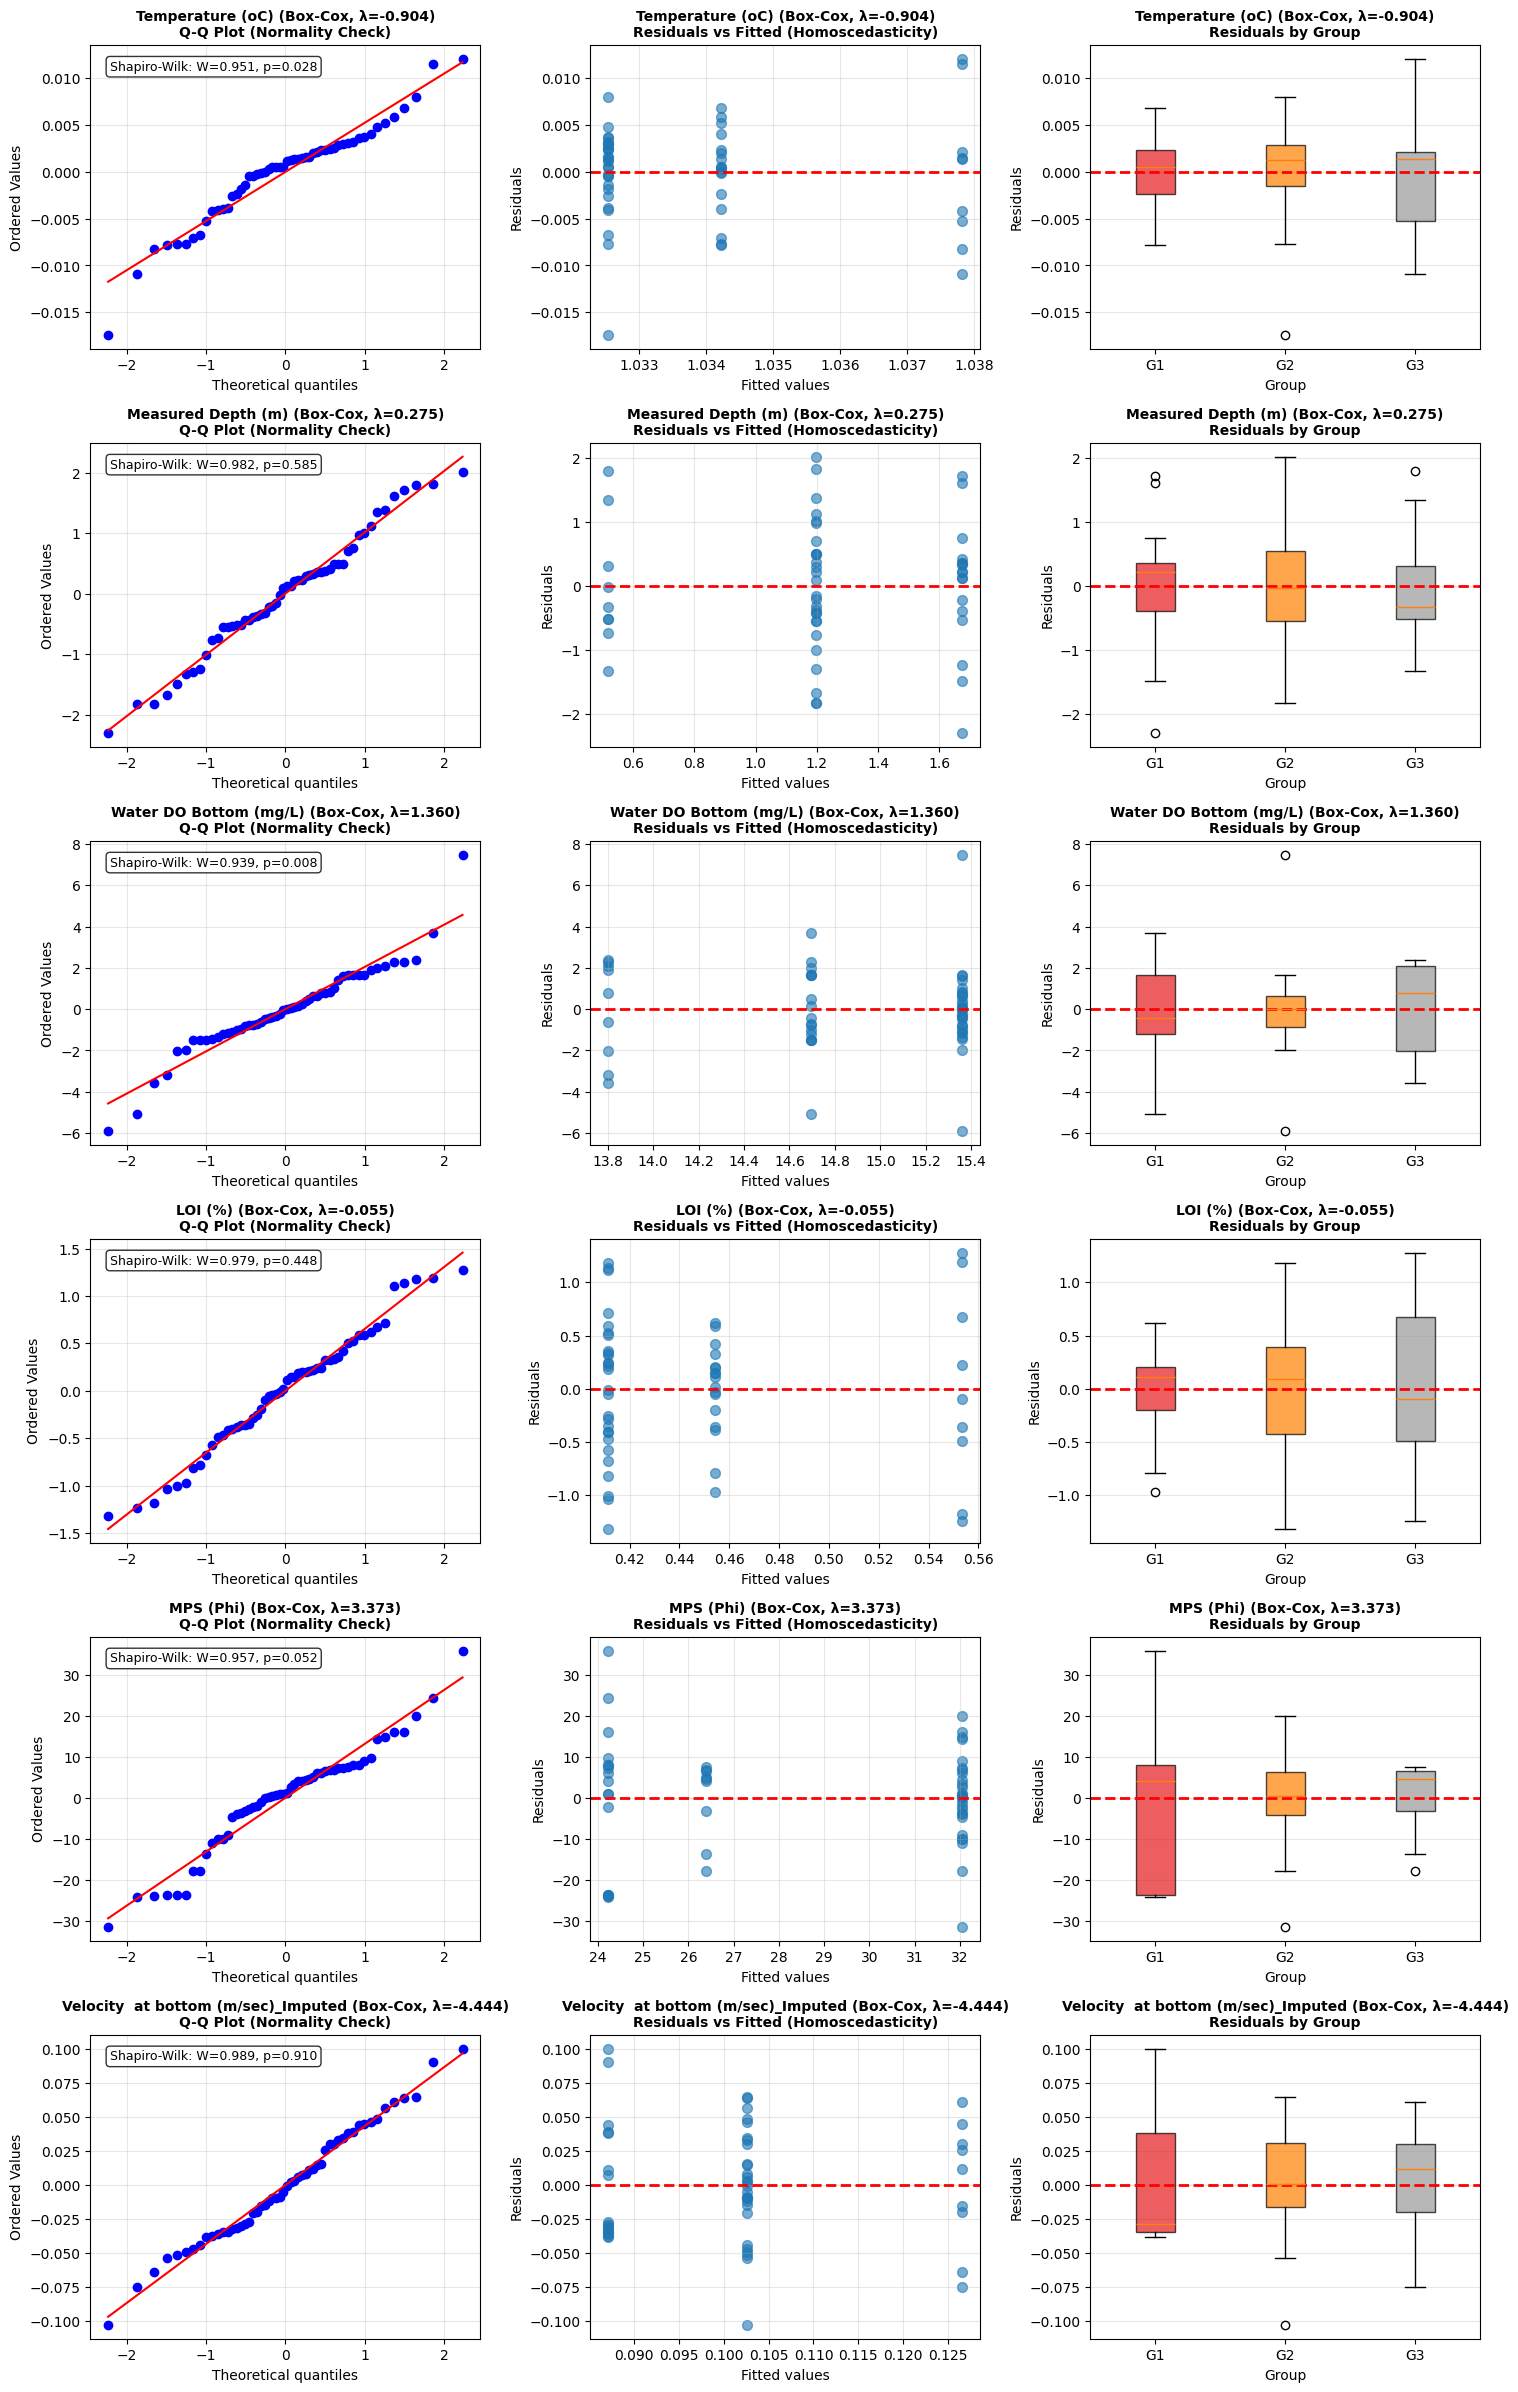

In [2829]:
# visualize the asumption assessment for the Box-Cox transformed features
fig, axes = plt.subplots(len(env_features_anova), 3, figsize=(15, 4*len(env_features_anova)))

for idx, feature_boxcox in enumerate(env_features_boxcox):
    original_feature = env_features_anova[idx]
    lambda_val = boxcox_features[original_feature]['lambda']
    
    # Get data by group
    groups_data = []
    for group_id in range(n_groups):
        group_values = raw_reference_data[raw_reference_data['octave_groups'] == group_id][feature_boxcox].dropna()
        groups_data.append(group_values)
    
    # Calculate residuals
    group_means = [group.mean() for group in groups_data]
    residuals = []
    group_labels = []
    
    for group_id, group_data in enumerate(groups_data):
        group_residuals = group_data - group_means[group_id]
        residuals.extend(group_residuals)
        group_labels.extend([group_id] * len(group_residuals))
    
    residuals = np.array(residuals)
    group_labels = np.array(group_labels)
    
    # ========================================
    # Left: Q-Q Plot (Normality of Residuals)
    # ========================================
    ax1 = axes[idx, 0]
    # add Shapiro-Wilk test result on the plot
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    ax1.text(0.05, 0.95, f'Shapiro-Wilk: W={shapiro_stat:.3f}, p={shapiro_p:.3f}', 
             transform=ax1.transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    stats.probplot(residuals, dist="norm", plot=ax1)
    ax1.set_title(f'{original_feature} (Box-Cox, λ={lambda_val:.3f})\nQ-Q Plot (Normality Check)', 
                  fontsize=10, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # ========================================
    # Middle: Residuals vs Fitted (Homoscedasticity)
    # ========================================
    ax2 = axes[idx, 1]
    fitted_values = np.concatenate([np.full(len(g), group_means[i]) for i, g in enumerate(groups_data)])
    
    ax2.scatter(fitted_values, residuals, alpha=0.6, s=50)
    ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax2.set_xlabel('Fitted values', fontsize=10)
    ax2.set_ylabel('Residuals', fontsize=10)
    ax2.set_title(f'{original_feature} (Box-Cox, λ={lambda_val:.3f})\nResiduals vs Fitted (Homoscedasticity)', 
                  fontsize=10, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # ========================================
    # Right: Boxplot of residuals by group
    # ========================================
    ax3 = axes[idx, 2]
    residuals_by_group = [residuals[group_labels == i] for i in range(n_groups)]
    
    bp = ax3.boxplot(residuals_by_group, tick_labels=[f'G{i+1}' for i in range(n_groups)],
                     patch_artist=True)
    
    # Color boxes
    colors = plt.cm.Set1(np.linspace(0, 1, n_groups))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax3.set_xlabel('Group', fontsize=10)
    ax3.set_ylabel('Residuals', fontsize=10)
    ax3.set_title(f'{original_feature} (Box-Cox, λ={lambda_val:.3f})\nResiduals by Group', 
                  fontsize=10, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.subplots_adjust(top=0.98)
plt.show()

Based on the **Box-Cox** transformation, though some features still did not fully meet the ANOVA assumptions, overall the assumptions are much better satisfied than before transformation.

Therefore, we can proceed to do ANOVA on the Box-Cox transformed habitat features across the clusters.

#### ANOVA on Box-Cox transformed habitat features across the clusters

In [2851]:
from scipy.stats import f_oneway

# Perform ANOVA on Box-Cox transformed features across the taxa assemblage groups
print("=" * 120)
print("ONE-WAY ANOVA: Box-Cox Transformed Habitat Features Across Taxa Assemblage Groups")
print("=" * 120)
print(f"\nNull Hypothesis (H₀): Group means are equal for each environmental feature")
print(f"Alternative Hypothesis (H₁): At least one group mean differs")
print(f"Significance level: α = 0.05")
print(f"\nNumber of groups: {n_groups}")
print(f"Total sites: {len(raw_reference_data)}")
print(f"Sites per group: {cluster_groups.value_counts().sort_index().to_dict()}")

# Store ANOVA results
anova_results = []

for idx, feature_boxcox in enumerate(env_features_boxcox):
    original_feature = env_features_anova[idx]
    
    # Get data by group
    groups_data = []
    for group_id in range(n_groups):
        group_values = raw_reference_data[raw_reference_data['octave_groups'] == group_id][feature_boxcox].dropna()
        groups_data.append(group_values)
    
    # Perform one-way ANOVA
    f_stat, p_value = f_oneway(*groups_data)
    
    # Determine significance
    is_significant = p_value < 0.05
    
    # Store results
    anova_results.append({
        'Original_Feature': original_feature,
        'Transformed_Feature': feature_boxcox,
        'F_statistic': f_stat,
        'p_value': p_value,
        'Significant': is_significant
    })

# Create compact table output
anova_df = pd.DataFrame(anova_results)

# Table: ANOVA Results
print("\n┌─ ANOVA Results: Box-Cox Transformed Features ─" + "─" * 70 + "┐")
print("│")
print("│  Feature                     │  F-statistic │  p-value   │  Significant  │")
print("│" + "─" * 30 + "┼" + "─" * 14 + "┼" + "─" * 12 + "┼" + "─" * 15 + "│")

for _, row in anova_df.iterrows():
    feature_short = row['Original_Feature'][:27] + '...' if len(row['Original_Feature']) > 27 else row['Original_Feature']
    sig_mark = "✓ (p < 0.05)" if row['Significant'] else "✗ (p ≥ 0.05)"
    print(f"│  {feature_short:<28} │  {row['F_statistic']:>10.4f}  │  {row['p_value']:>8.4f}  │  {sig_mark:<13} │")

print("│")
print("└" + "─" * 118 + "┘")

# Summary
n_significant = anova_df['Significant'].sum()
n_total = len(anova_df)

print(f"\n┌─ ANOVA Summary ─" + "─" * 20 + "┐")
print("│")
print(f"│  Significant differences: {n_significant}/{n_total}   │")
print("│")
print("└" + "─" * 38 + "┘")

print("\nInterpretation:")
if n_significant > 0:
    print(f"  • {n_significant} feature(s) show significant differences across taxa assemblage groups (p < 0.05)")
    print(f"  • These features may be important environmental drivers of taxa assemblage structure")
else:
    print(f"  • No features show significant differences across groups")
    print(f"  • Taxa assemblages may be driven by other factors not measured here")

ONE-WAY ANOVA: Box-Cox Transformed Habitat Features Across Taxa Assemblage Groups

Null Hypothesis (H₀): Group means are equal for each environmental feature
Alternative Hypothesis (H₁): At least one group mean differs
Significance level: α = 0.05

Number of groups: 3
Total sites: 54
Sites per group: {0: 17, 1: 28, 2: 9}

┌─ ANOVA Results: Box-Cox Transformed Features ───────────────────────────────────────────────────────────────────────┐
│
│  Feature                     │  F-statistic │  p-value   │  Significant  │
│──────────────────────────────┼──────────────┼────────────┼───────────────│
│  Temperature (oC)             │      3.3185  │    0.0442  │  ✓ (p < 0.05)  │
│  Measured Depth (m)           │      3.8653  │    0.0274  │  ✓ (p < 0.05)  │
│  Water DO Bottom (mg/L)       │      1.9525  │    0.1524  │  ✗ (p ≥ 0.05)  │
│  LOI (%)                      │      0.1621  │    0.8508  │  ✗ (p ≥ 0.05)  │
│  MPS (Phi)                    │      1.9587  │    0.1515  │  ✗ (p ≥ 0.05)  │
│  Ve

## ANOVA on Taxa Variables Across Cluster Groups

Similar to the environmental variables analysis, we will:

- Apply Box-Cox transformation to taxa variables in `taxa_ref_octave`
   
- Perform ANOVA to test if taxa abundances differ significantly across the `octave_groups` levels

In [2831]:
# apply Box-Cox transformation to taxa reference octave data
from scipy.stats import boxcox
from scipy import stats

# Get octave_groups from raw_reference_data
octave_groups = raw_reference_data['octave_groups'].copy()

# Store Box-Cox transformed taxa and their lambda values
taxa_boxcox_features = {}
taxa_lambda_values = {}

# Apply Box-Cox transformation to each taxon
for taxon in taxa_ref_octave.columns:
    
    # Get the taxon data
    taxon_data = taxa_ref_octave[taxon].copy()
    
    # Check if all values are positive
    min_val = taxon_data.min()
    
    # Box-Cox requires positive values, shift if necessary
    if min_val <= 0:
        shift_value = abs(min_val) + 1e-6  # Small epsilon to ensure positivity
        taxon_data_shifted = taxon_data + shift_value
        
    else:
        taxon_data_shifted = taxon_data
        shift_value = 0
    
    # Apply Box-Cox transformation and find optimal lambda
    try:
        transformed_data, optimal_lambda = boxcox(taxon_data_shifted)
        
        # Store the transformation
        taxa_boxcox_features[taxon] = {
            'transformed': transformed_data,
            'lambda': optimal_lambda,
            'shift': shift_value
        }
        taxa_lambda_values[taxon] = optimal_lambda
        
    except Exception as e:
        print(f"  - ERROR: Could not transform {taxon}: {str(e)}")
        continue

print(f"✓ Box-Cox transformation completed for {len(taxa_boxcox_features)} taxa")

✓ Box-Cox transformation completed for 16 taxa


In [2832]:
# do ANOVA on Box-Cox transformed taxa variables across octave groups
from scipy.stats import f_oneway, shapiro, levene

# Prepare data structure for ANOVA results
taxa_anova_results = []

# Perform ANOVA for each Box-Cox transformed taxon
for taxon, transform_info in taxa_boxcox_features.items():
        
    transformed_data = transform_info['transformed']
    
    # Split data by octave groups
    groups_data = []
    for group_id in sorted(octave_groups.unique()):
        group_mask = octave_groups == group_id
        group_data = transformed_data[group_mask]
        groups_data.append(group_data)
    
    # Test ANOVA assumptions
    # 1. Normality test (Shapiro-Wilk) for each group
    normality_pass = True
    for i, group_data in enumerate(groups_data):
        if len(group_data) >= 3:  # Need at least 3 samples for Shapiro-Wilk
            shapiro_stat, shapiro_p = shapiro(group_data)
            if shapiro_p < 0.05:
                normality_pass = False
    
    # 2. Homogeneity of variance test (Levene's test)
    levene_stat, levene_p = levene(*groups_data)
    variance_pass = levene_p >= 0.05
    
    # Perform one-way ANOVA
    f_stat, p_value = f_oneway(*groups_data)
    
    # Determine significance
    is_significant = p_value < 0.05
    significance = "***" if p_value < 0.001 else ("**" if p_value < 0.01 else ("*" if p_value < 0.05 else "ns"))
    
    # Store results
    taxa_anova_results.append({
        'Taxon': taxon,
        'Lambda': transform_info['lambda'],
        'F-statistic': f_stat,
        'p-value': p_value,
        'Significance': significance,
        'Normality': '✓' if normality_pass else '✗',
        'Homogeneity': '✓' if variance_pass else '✗'
    })

print("One-Way ANOVA has been performed on Box-Cox transformed taxa variables.")

One-Way ANOVA has been performed on Box-Cox transformed taxa variables.


In [2833]:
# print the summary table of ANOVA results of taxa variables
taxa_anova_df = pd.DataFrame(taxa_anova_results)
taxa_anova_df = taxa_anova_df.sort_values('p-value')

print(f"\n{'='*70}")
print("ANOVA Results Summary (sorted by p-value):")
print(f"{'='*70}\n")

# Reorder columns to put Lambda before Normality and Homogeneity
column_order = ['Taxon', 'F-statistic', 'p-value', 'Significance', 'Lambda', 'Normality', 'Homogeneity']
taxa_anova_df_reordered = taxa_anova_df[column_order].round(6)

print(taxa_anova_df_reordered.to_string(index=False))

# Summary statistics
n_significant = (taxa_anova_df['p-value'] < 0.05).sum()
n_total = len(taxa_anova_df)

print(f"\n{'='*70}")
print(f"Summary:")
print(f"  - Total taxa analyzed: {n_total}")
print(f"  - Significant differences (p < 0.05): {n_significant} ({100*n_significant/n_total:.1f}%)")
print(f"  - Non-significant: {n_total - n_significant} ({100*(n_total-n_significant)/n_total:.1f}%)")
print(f"{'='*70}")


ANOVA Results Summary (sorted by p-value):

            Taxon  F-statistic  p-value Significance    Lambda Normality Homogeneity
        Dreissena    27.037221 0.000000          *** -0.012829         ✗           ✗
           Caenis    15.589631 0.000005          *** -0.087970         ✗           ✓
       Gastropoda    14.370566 0.000011          *** -0.006450         ✗           ✓
      Oligochaeta    12.814054 0.000031          ***  0.915496         ✗           ✓
        Amphipoda     9.212529 0.000384          *** -0.046705         ✗           ✓
     Chironomidae     5.757373 0.005565           **  0.638491         ✗           ✓
         Hydrozoa     1.846979 0.168107           ns -0.149977         ✗           ✓
         Nematoda     1.804247 0.174946           ns  0.190243         ✗           ✓
      Turbellaria     1.302285 0.280797           ns -0.088166         ✗           ✓
  Ceratopogonidae     1.008002 0.372101           ns -0.430064         ✗           ✓
      Sphaeriidae   

## Iteracting R code in Python: Setup `rpy2` entension

To run R code within this Python notebook, we use the `rpy2` package which provides seamless integration between Python and R.

In [2834]:
# Load rpy2 extension to enable R magic commands
%load_ext rpy2.ipython

print("✓ rpy2 loaded successfully!")
print("You can now use %%R at the start of a cell to run R code")
print("Or use %R for inline R commands")

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
✓ rpy2 loaded successfully!
You can now use %%R at the start of a cell to run R code
Or use %R for inline R commands


### Example 1: Basic R Code Execution

Use `%%R` at the start of a cell to run R code directly:

Mean of x: 3 
Correlation between x and y: 1 


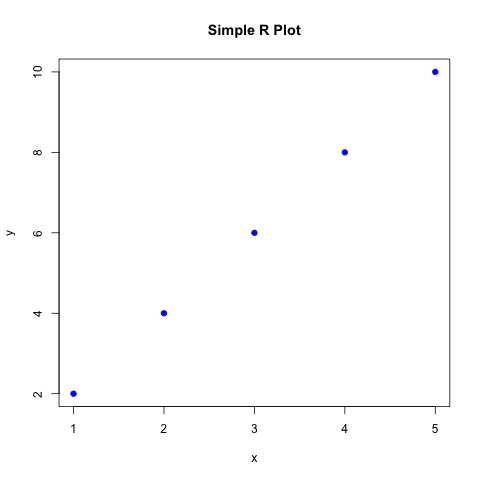

In [2835]:
%%R
# This entire cell runs in R
x <- c(1, 2, 3, 4, 5)
y <- c(2, 4, 6, 8, 10)
mean_x <- mean(x)
cor_xy <- cor(x, y)

cat("Mean of x:", mean_x, "\n")
cat("Correlation between x and y:", cor_xy, "\n")

# Create a simple plot
plot(x, y, main="Simple R Plot", col="blue", pch=19)

### Example 2: Pass Data from Python to R

Use `-i` flag to pass Python variables into R:

In [2836]:
# Create a pandas DataFrame in Python
import pandas as pd
import numpy as np

py_data = pd.DataFrame({
    'station': range(1, 11),
    'temperature': np.random.uniform(15, 25, 10),
    'depth': np.random.uniform(5, 50, 10)
})

print("Python DataFrame created:")
print(py_data.head())

Python DataFrame created:
   station  temperature      depth
0        1    18.454882  18.565821
1        2    20.815541  46.170740
2        3    23.923995  40.010208
3        4    17.508292  46.315026
4        5    24.789308  22.380235


In [2837]:
%%R -i py_data
# py_data is now available in R
print("Data passed from Python to R:")
print(head(py_data))

# Run R analysis
summary_stats <- summary(py_data)
print(summary_stats)

# Correlation
correlation <- cor(py_data$temperature, py_data$depth)
cat("\nCorrelation between temperature and depth:", correlation, "\n")

[1] "Data passed from Python to R:"
  station temperature    depth
0       1    18.45488 18.56582
1       2    20.81554 46.17074
2       3    23.92400 40.01021
3       4    17.50829 46.31503
4       5    24.78931 22.38024
5       6    17.81697 36.88150
    station       temperature        depth      
 Min.   : 1.00   Min.   :17.51   Min.   :16.71  
 1st Qu.: 3.25   1st Qu.:18.68   1st Qu.:25.46  
 Median : 5.50   Median :20.50   Median :37.26  
 Mean   : 5.50   Mean   :21.05   Mean   :34.79  
 3rd Qu.: 7.75   3rd Qu.:23.82   3rd Qu.:44.63  
 Max.   :10.00   Max.   :24.79   Max.   :48.55  

Correlation between temperature and depth: 0.01647646 


### Example 3: Get Results Back from R to Python

Use `-o` flag to retrieve R variables back into Python:

In [2838]:
%%R -i py_data -o r_result
# Process data in R and return result
r_result <- data.frame(
    mean_temp = mean(py_data$temperature),
    mean_depth = mean(py_data$depth),
    sd_temp = sd(py_data$temperature),
    sd_depth = sd(py_data$depth)
)
print(r_result)

  mean_temp mean_depth  sd_temp sd_depth
1  21.05168   34.79243 2.819217 11.71629


In [2839]:
# Now r_result is available in Python
print("R result retrieved in Python:")
print(r_result)
print(f"\nType: {type(r_result)}")

R result retrieved in Python:
   mean_temp  mean_depth   sd_temp   sd_depth
1  21.051677   34.792432  2.819217  11.716287

Type: <class 'pandas.core.frame.DataFrame'>


## Identify Indicator Species with Species Clustering (R-Mode)

From the page **112** of the book **Numerical Ecology with R**.

We use the Kendall's W Coefficient of Concordance to assess the agreement among species in their response across sites. That is:

**Species are concordant if they show similar patterns of abundance variation across the set of sites.**

In [2840]:
# load Python magic extension for running R code
import os
import sys

# Point to Homebrew R installation
os.environ['R_HOME'] = '/opt/homebrew/Cellar/r/4.5.2_1/lib/R'
os.environ['R_USER'] = os.path.expanduser('~')

# Suppress stderr during rpy2 import to hide ABI fallback messages
class SuppressStderr:
    def __enter__(self):
        self.stderr = sys.stderr
        sys.stderr = open(os.devnull, 'w')
        return self
    
    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stderr.close()
        sys.stderr = self.stderr

# Load rpy2 with suppressed stderr
with SuppressStderr():
    %load_ext rpy2.ipython

print("✓ rpy2 loaded successfully!")
print("You can now use %%R at the start of a cell to run R code")
print("Or use %R for inline R commands")

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
✓ rpy2 loaded successfully!
You can now use %%R at the start of a cell to run R code
Or use %R for inline R commands


In [2841]:
%%R
# Load the installed packages and verify they work

library(vegan)
library(indicspecies)

# Print package versions
cat("Package versions:\n")
cat("- vegan:", as.character(packageVersion("vegan")), "\n")
cat("- indicspecies:", as.character(packageVersion("indicspecies")), "\n")

Package versions:
- vegan: 2.7.2 
- indicspecies: 1.8.0 


Prepare the cluster labels obtained from Ward's hierarchical clustering on Octave transformed data with Euclidean distance measure.

In [2842]:
# extract the taxa data and do transformations in R
ref_cluster_labels = raw_reference_data['octave_groups'].copy()
print("✓ Taxa data extracted for Kendall's W Coefficient of Concordance R")
print("taxa_ref shape:", taxa_ref.shape)
print("ref_cluster_labels shape:", ref_cluster_labels.shape)

✓ Taxa data extracted for Kendall's W Coefficient of Concordance R
taxa_ref shape: (54, 16)
ref_cluster_labels shape: (54,)


Run an overall Kendall's W test to check if the species are not concordant (independent) across all sites.

In [2843]:
%%R -i taxa_ref

# transformation of species data and transposition
taxa_ref.hel <- decostand(taxa_ref, "hellinger")
taxa_ref.std <- decostand(taxa_ref, "standardize")
taxa_ref.t <- t(taxa_ref.std)
print("The raw species data of ref sites have been transformed and transposited successfully.")

# first run a test of Kendall concordance involving all species
taxa_ref.kendall.global1 <- kendall.global(taxa_ref.hel)
taxa_ref.kendall.global1
print(taxa_ref.kendall.global1)
print("✓ Kendall's W Coefficient of Concordance for all species calculated")
print("Null hypothesis: No agreement in species abundances across sites")

[1] "The raw species data of ref sites have been transformed and transposited successfully."
$Concordance_analysis
              Group.1
W          0.09680055
F          1.60762752
Prob.F     0.00478825
Chi2      82.08686869
Prob.perm  0.00900000

attr(,"class")
[1] "kendall.global"
[1] "✓ Kendall's W Coefficient of Concordance for all species calculated"
[1] "Null hypothesis: No agreement in species abundances across sites"


After the global test is passed ($H_0$ is rejected).

First, run a clustering on the species level, to group the possible concordant taxa into a same group.


✓ Enhanced cascadeKM visualization created
Optimal number of clusters: 2 
Calinski-Harabasz index: 2.8 


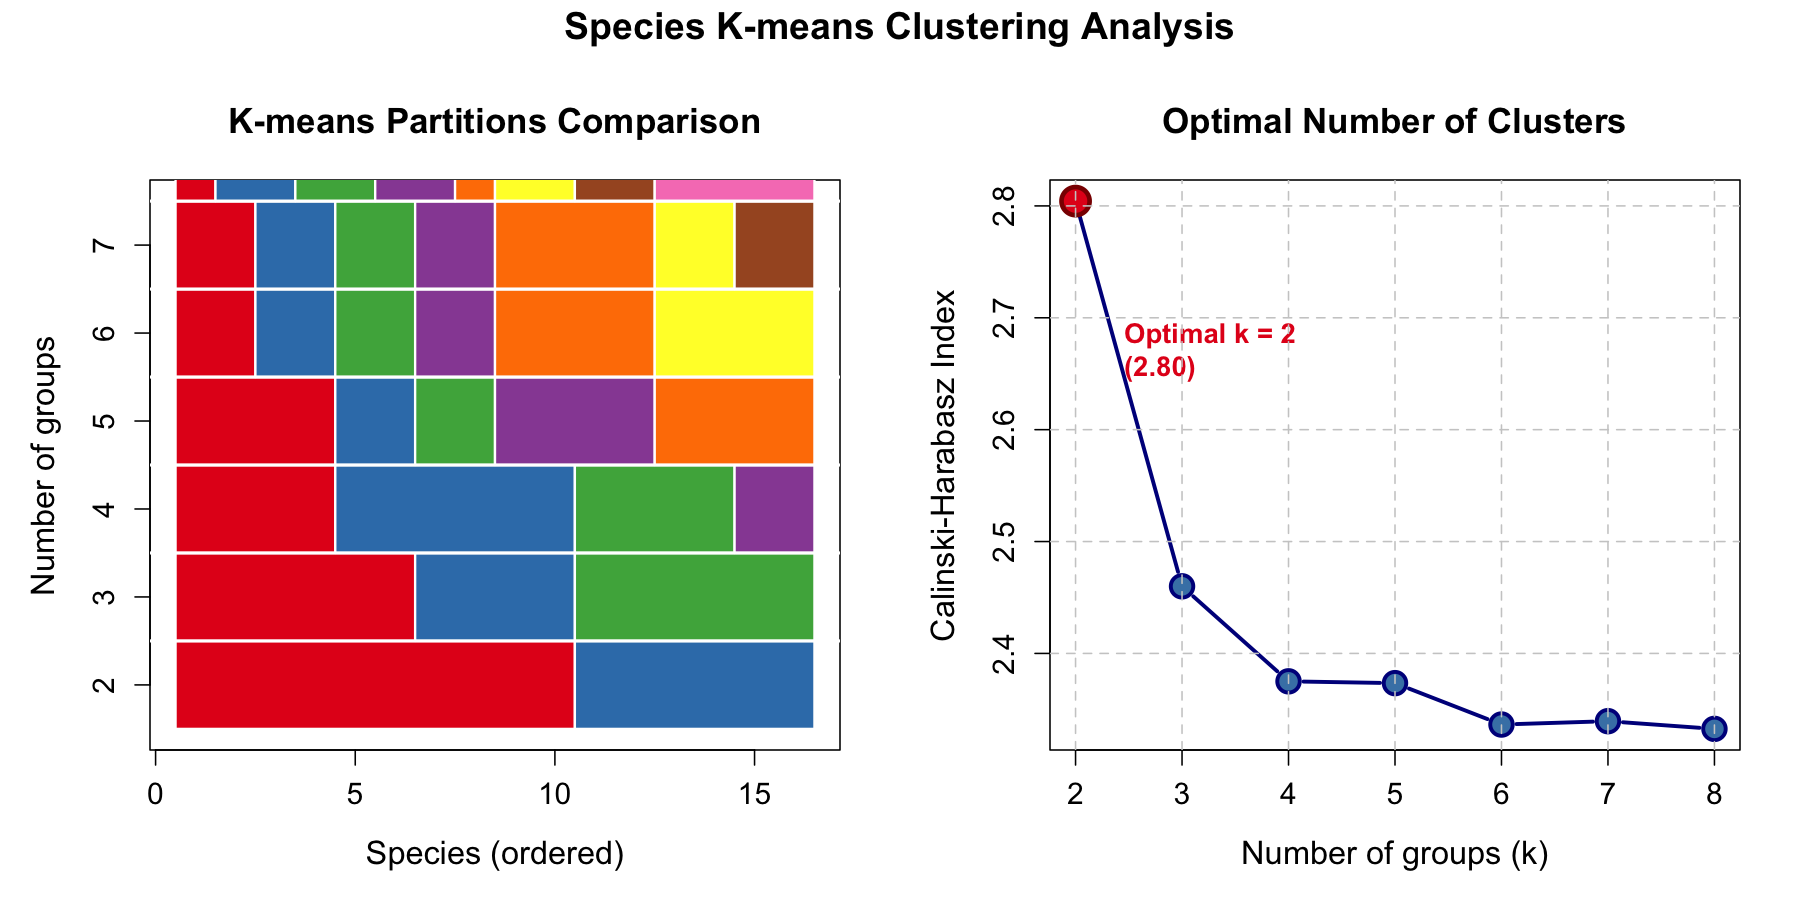

In [2844]:
%%R -i ref_cluster_labels -w 12 -h 6 --units in -r 150

# k-means partitioning of species
taxa_ref.t.kmeans.casc <- cascadeKM(
    taxa_ref.t,
    inf.gr = 2,
    sup.gr = 8,
    iter = 100,
    criterion = "calinski"
)

# Create a high-quality visualization with custom layout
par(mfrow = c(1, 2), mar = c(5, 5, 4, 2), oma = c(0, 0, 2, 0))

# Left panel: Partition comparison with custom colors
# Get the partition data
partitions <- taxa_ref.t.kmeans.casc$partition
n_species <- nrow(partitions)
n_k <- ncol(partitions)

# Create color palette - use distinct colors for clusters
color_palette <- c("#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", 
                   "#FF7F00", "#FFFF33", "#A65628", "#F781BF")

# Create partition plot
plot(1, type = "n", xlim = c(0.5, n_species + 0.5), ylim = c(1.5, n_k + 0.5),
     xlab = "Species (ordered)", ylab = "Number of groups", 
     main = "K-means Partitions Comparison",
     cex.lab = 1.3, cex.axis = 1.2, cex.main = 1.4, font.main = 2)

# Draw colored rectangles for each partition
for (k in 1:n_k) {
    k_value <- k + 1  # k ranges from 2 to 8
    clusters <- partitions[, k]
    
    # Sort species by cluster assignment
    sorted_idx <- order(clusters)
    sorted_clusters <- clusters[sorted_idx]
    
    # Draw rectangles for each cluster
    x_pos <- 0
    for (cluster_id in 1:k_value) {
        cluster_members <- which(sorted_clusters == cluster_id)
        if (length(cluster_members) > 0) {
            rect(x_pos + 0.5, k + 0.5, x_pos + length(cluster_members) + 0.5, k + 1.5,
                 col = color_palette[cluster_id], border = "white", lwd = 1.5)
            x_pos <- x_pos + length(cluster_members)
        }
    }
}

# Add grid for clarity
abline(h = (2:n_k) + 0.5, col = "white", lwd = 2)

# Right panel: Calinski criterion values
calinski_values <- taxa_ref.t.kmeans.casc$results[2, ]
k_values <- 2:8

plot(k_values, calinski_values, type = "b", pch = 21, bg = "steelblue", 
     col = "darkblue", lwd = 2.5, cex = 2,
     xlab = "Number of groups (k)", ylab = "Calinski-Harabasz Index",
     main = "Optimal Number of Clusters",
     cex.lab = 1.3, cex.axis = 1.2, cex.main = 1.4, font.main = 2,
     xaxt = "n")

# Add x-axis with integer values only
axis(1, at = k_values, labels = k_values, cex.axis = 1.2)

# Highlight the optimal k (maximum Calinski value)
optimal_k <- k_values[which.max(calinski_values)]
optimal_value <- max(calinski_values)
points(optimal_k, optimal_value, pch = 21, bg = "#E41A1C", 
       col = "darkred", cex = 2.5, lwd = 3)

# Add text annotation for optimal k (positioned to the right and lower)
text(optimal_k + 0.4, optimal_value - optimal_value * 0.05, 
    labels = sprintf("Optimal k = %d\n(%.2f)", optimal_k, optimal_value),
    pos = 4, cex = 1.1, col = "#E41A1C", font = 2, offset = 0.2)

# Add grid for better readability
grid(col = "gray80", lty = 2)

# Add overall title
mtext("Species K-means Clustering Analysis", outer = TRUE, cex = 1.5, font = 2, line = 0.5)

cat("\n✓ Enhanced cascadeKM visualization created\n")
cat("Optimal number of clusters:", optimal_k, "\n")
cat("Calinski-Harabasz index:", round(optimal_value, 2), "\n")

Run the global Kendall's W test on each species cluster to check if the species are concordant within the cluster.

In [2845]:
%%R

# take the optimal species clusters from k-means method
clusters2 <- taxa_ref.t.kmeans.casc$partition[, 1]
clusters3 <- taxa_ref.t.kmeans.casc$partition[, 2] # a comparison one 

# a global Kendall W test (concordance analysis) on each of the clusters
taxa_ref.kendall.global2 <- kendall.global(taxa_ref.hel, clusters2)
taxa_ref.kendall.global2

$Concordance_analysis
                         Group.1      Group.2
W                   2.120968e-01  0.254020287
F                   2.422723e+00  1.702595139
Prob.F              4.906273e-07  0.003669894
Corrected prob.F    9.812546e-07  0.003669894
Chi2                1.124113e+02 80.778451178
Prob.perm           1.000000e-03  0.005000000
Corrected prob.perm 2.000000e-03  0.005000000

$Correction.type
[1] "holm"

attr(,"class")
[1] "kendall.global"


The rejecting of $H_0$ in each of the clusters means there is concordance among the species in the clusters.

Then, run a **posteriori tests** to identify the significantly concordant concordant species within each cluster.

In [2846]:
%%R

# A posteriori test across the optimal clusters from k-means
taxa_ref.kendall.post2 <- kendall.post(taxa_ref.hel, clusters2, nperm = 9999)

This posteriori test in each cluster identifies the species that contribute significantly to the overall concordance of the cluster. Explanation follows.

## R-Mode Results: Concordant Species in the Two Assemblages (Kendall’s W Posteriori Test)

K-means clustering and Kendall’s W identified **two major species assemblages** that represent distinct ecological responses across the study area.



### **Assemblage 1 – Soft-Bottom, Low-Flow Guild**

This assemblage contains taxa strongly associated with **fine sediments**, **low water velocity**, **higher organic content**, and **depositional environments** such as delta channels and sheltered embayments.

#### Significant Concordant Species (corrected p < 0.05)

| Species            | Spearman.mean | W.per.species | Corrected p-value | Ecological Meaning                                   |
|-------------------|----------------|----------------|--------------------|-------------------------------------------------------|
| Ceratopogonidae   | 0.2763         | 0.3420         | 0.0016             | Fine-sediment, low-flow tolerant                      |
| Chironomidae      | 0.2614         | 0.3286         | 0.0016             | Core soft-bottom taxon; depositional habitats         |
| Hirudinea         | 0.2273         | 0.2975         | 0.0016             | Low-flow, fine-sediment environments                  |
| Oligochaeta       | 0.2536         | 0.3214         | 0.0016             | Organic-rich, fine-sediment indicator                 |

**Non-significant contributors:** Acari, Caenis, Hexagenia, Gastropoda, Nematoda, Trichoptera, Sphaeriidae, Other.

---

### **Assemblage 2 – High-Flow, Coarse-Substrate Guild**

This assemblage represents species favored by **higher water velocities**, **coarse or hard substrates**, and **oxygen-rich, well-flushed conditions** typical of riverine or energetic open-lake environments.

#### Significant Concordant Species (corrected p < 0.05)

| Species     | Spearman.mean | W.per.species | Corrected p-value | Ecological Meaning                                   |
|-------------|----------------|----------------|--------------------|-------------------------------------------------------|
| Hydrozoa    | 0.2642         | 0.4114         | 0.0016             | High-flow, well-oxygenated habitats                   |
| Turbellaria | 0.2134         | 0.3708         | 0.0310             | Coarse substrate, moderate–high energy environments    |

**Non-significant contributors:** Amphipoda, Dreissena, Hydropsychidae.

---

### **Ecological Summary**

The two assemblages reflect a dominant ecological gradient:

- **Assemblage 1:** low-energy, depositional, fine-sediment environments.  
- **Assemblage 2:** high-energy, erosional, coarse-substrate environments.  

These species groups highlight how benthic community structure is shaped primarily by **sediment texture**, **hydrodynamic regime**, and **associated oxygen and organic matter conditions**.


## Output the clustering results with complete data

At the beginning, we imported the `data` with pollution socres,
through this analysis process, we got the clustering results from **Ward's clustering on octave transformed taxa with Euclidean distance**.

The clustering labels are merged back into the `data`, which will be passed to next stage - **Discriminant Function Analysis**.

In [2847]:
# merge the clustering results back to complete raw data

# fetch the computed results: cluster labels
cluster_labels = raw_reference_data["octave_groups"].copy()

# merge them back to raw data
data[("ref_sites_clusters", "wards_hellinger_euc", "labels")] = cluster_labels

In [2848]:
# reorder the columns for better readability
cols = data.columns.tolist()

# Find the velocity column index
velocity_col = ('environmental', 'raw', 'Velocity at bottom (m/sec)_Imputed')
velocity_idx = cols.index(velocity_col)

# Find all environmental-raw columns
env_raw_velocity_idx = cols.index(('environmental', 'raw', 'Velocity at bottom (m/sec)_Imputed')) + 1

# Remove the velocity column from its current position
cols_reordered = cols[:velocity_idx] + cols[velocity_idx+1:]

# Insert it next to the original velocity column position
cols_reordered.insert(env_raw_velocity_idx, velocity_col)

# Reorder the dataframe
data = data[cols_reordered]

print("✓ Velocity column moved to front of environmental-raw subblock")
print(f"New column order in environmental-raw:")
env_raw_cols_new = [col for col in data.columns if col[0] == 'environmental' and col[1] == 'raw']
for i, col in enumerate(env_raw_cols_new):
    print(f"  {i+1}. {col[2]}")

✓ Velocity column moved to front of environmental-raw subblock
New column order in environmental-raw:
  1. LOI (%)
  2. MPS (Phi)
  3. Measured Depth (m)
  4. Temperature (oC)
  5. Velocity  at bottom (m/sec)
  6. Water DO Bottom (mg/L)
  7. Velocity at bottom (m/sec)_Imputed


In [2849]:
# output the merged complete data to a new file
import time
from datetime import datetime
# output the merged complete data to a new file with timestamp
datetime = datetime.now().strftime("%m_%d_%H_%M")
filename = f"../data/processed/03_Cluster_Reference_Sites/03_data_with_ref_clusters_{datetime}.xlsx"
data.to_excel(filename)
print(f"✓ Data exported to: {filename}")

✓ Data exported to: ../data/processed/03_Cluster_Reference_Sites/03_data_with_ref_clusters_01_04_21_38.xlsx
